# RL Demo: From Value Iteration to DQN, and Why We Still Need Policy Gradient

A progressive demo using the same 2D MuJoCo crawler throughout. Each method solves one bottleneck, then fails when we make the problem slightly more realistic.

| Demo | Algorithm | State | Actions | Result | Bottleneck / Lesson |
|------|-----------|-------|---------|--------|---------------------|
| 0A | Value Iteration | 2D discrete angles (81 states) | 4 discrete | Barely works | Needs model access, and the 2D state is not Markov |
| 1A-1B | Tabular Q-learning | 2D discrete angles | 4 discrete | Works, but reward design matters | Learns from experience, no model needed |
| 2 | Tabular Q-learning | 4D discrete (angles + velocities) | 4 discrete | Breaks | Curse of dimensionality |
| 3 | DQN | 4D continuous state | 4 discrete | Works | Neural network handles large/continuous state spaces |
| 3A-3B | DQN diagnostics | 4D continuous state | 4 discrete | Explain why DQN needs replay, target networks, and Double DQN | Stabilization matters |
| 4 | DQN with finer action discretization | 4D continuous state | 49-121 discrete | Breaks | Discrete-action argmax does not scale to continuous control |

**Default reward used in most demos:** at each simulator step,

$$r_t = \frac{x_{t+1} - x_t}{\Delta t}$$

where `x` is the crawler's forward torso position. So the agent is rewarded for **forward velocity**. Episode reward is the sum of these per-step rewards, which is why higher total reward usually means the crawler traveled farther over the rollout.

**Important assumption:** for this default reward, we assume we have direct access to the torso's **global** position even when the observation/state given to the policy does **not** include torso position. That means we are assuming a fairly good external state estimator for the robot's global position. In simulation this is easy, but on a real robot this is usually not directly true. Later in the sim2real lecture we will see how to deal with that by augmenting the state space and using a few other practical tricks.

**Exception:** Demo 1B intentionally changes the reward to final distance after 10s, to show how reward design changes what tabular Q-learning learns.

In [1]:
# Setup - run this first
!pip install -q mujoco

import os
import numpy as np
import mujoco
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML, display
from pathlib import Path
import collections
import time

# Check if torch is available (pre-installed on Colab)
import torch
import torch.nn as nn
import torch.optim as optim

print(f'MuJoCo version: {mujoco.__version__}')
print(f'PyTorch version: {torch.__version__}')
print('Setup complete!')

MuJoCo version: 3.6.0
PyTorch version: 2.11.0
Setup complete!


In [ ]:
# ============================================================
# Crawler Environment (imported from shared module)
# ============================================================
# The 2D MuJoCo crawler used across lectures 1-3 of the CMM26 RL series
# now lives in `envs/crawler2d.py`. This keeps L6-1 (tabular / DQN),
# L6-2 (policy gradient / actor-critic), and L6-3 (SAC, reward
# engineering, action spaces, domain randomisation) in lock-step.

from envs.crawler2d import CrawlerEnv, CRAWLER_XML

# ---------- Discrete action maps ----------
# 4 coarse actions: all combinations of +/- torque on each joint
ACTIONS_4 = {
    0: np.array([1.0, 1.0]),
    1: np.array([1.0, -1.0]),
    2: np.array([-1.0, 1.0]),
    3: np.array([-1.0, -1.0]),
}

def make_fine_actions(n_bins):
    """Create a grid of n_bins^2 discrete torque pairs."""
    torques = np.linspace(-1, 1, n_bins)
    actions = {}
    idx = 0
    for a in torques:
        for b in torques:
            actions[idx] = np.array([a, b])
            idx += 1
    return actions

print('Environment defined. Let\'s see what our crawler looks like!')


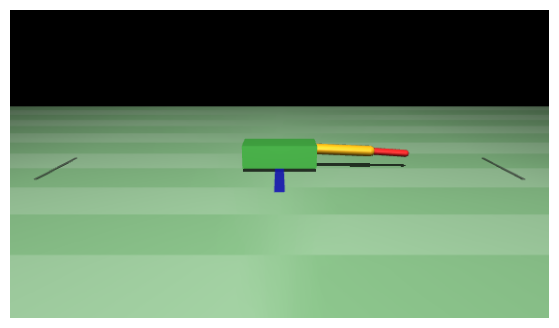

In [4]:
# ============================================================
# Visualization helpers
# ============================================================

# Collect eval results across demos for final comparison
eval_results = {}
eval_rollouts = {}

ROLLOUT_DIR = Path('saved_rollouts')
ROLLOUT_DIR.mkdir(exist_ok=True)


def rollout_slug(label):
    raw = label.lower().replace(' ', '_')
    return ''.join(ch if ch.isalnum() or ch in '._-' else '_' for ch in raw)


def save_rollout(frames, label, *, fps=30, distance=None, total_reward=None):
    """Persist a rollout so it can be reloaded without rerunning the notebook."""
    path = ROLLOUT_DIR / f'{rollout_slug(label)}.npz'
    np.savez_compressed(
        path,
        frames=np.asarray(frames, dtype=np.uint8),
        fps=np.int32(fps),
        label=np.asarray(label),
        distance=np.float32(distance if distance is not None else np.nan),
        total_reward=np.float32(total_reward if total_reward is not None else np.nan),
    )
    print(f'Saved rollout -> {path}')
    return path


def should_skip_rendering():
    """Best-effort detection of headless / remote sessions where OpenGL rendering is likely unavailable."""
    remote_markers = ('SSH_CONNECTION', 'SSH_CLIENT', 'SSH_TTY')
    is_remote = any(os.environ.get(name) for name in remote_markers)
    has_display = bool(os.environ.get('DISPLAY') or os.environ.get('WAYLAND_DISPLAY'))
    return is_remote and not has_display


def rollout_episode(env, policy_fn, max_steps=500):
    """Roll out a policy without rendering. Returns: (distance, total_reward)."""
    obs = env.reset()
    total_reward = 0.0
    for _ in range(max_steps):
        ctrl = policy_fn(obs)
        obs, reward, terminated, truncated, _ = env.step(ctrl)
        total_reward += reward
        if terminated or truncated:
            break
    dist = float(env.data.qpos[0])
    return dist, total_reward


def render_episode(env, policy_fn, max_steps=500, cam_name='side'):
    """Roll out a policy and collect rendered frames when OpenGL is available.
    
    policy_fn(obs) -> ctrl (2-element array of torques)
    Returns: (frames_or_none, distance, total_reward)
    """
    if should_skip_rendering():
        dist, total_reward = rollout_episode(env, policy_fn, max_steps=max_steps)
        print('Skipping video rendering: remote session without DISPLAY / Wayland detected.')
        return None, dist, total_reward

    try:
        renderer = mujoco.Renderer(env.model, height=320, width=560)
    except Exception as err:
        dist, total_reward = rollout_episode(env, policy_fn, max_steps=max_steps)
        print(f'Skipping video rendering: could not create OpenGL renderer ({type(err).__name__}: {err}).')
        return None, dist, total_reward

    frames = []
    obs = env.reset()
    total_reward = 0.0
    for _ in range(max_steps):
        renderer.update_scene(env.data, camera=cam_name)
        frames.append(renderer.render().copy())
        ctrl = policy_fn(obs)
        obs, reward, terminated, truncated, _ = env.step(ctrl)
        total_reward += reward
        if terminated or truncated:
            break
    dist = float(env.data.qpos[0])
    renderer.close()
    return frames, dist, total_reward


def eval_policy(env, policy_fn, label, max_steps=500):
    """Run a 10s rollout, render video, print distance, and persist the frames."""
    frames, dist, total_reward = render_episode(env, policy_fn, max_steps=max_steps)
    rollout_path = None
    if frames is not None and len(frames) > 0:
        rollout_path = save_rollout(frames, label, fps=30, distance=dist, total_reward=total_reward)
    print(f'{label}: traveled {dist:.2f}m in 10s  (episode reward: {total_reward:.1f})')
    eval_results[label] = dist
    eval_rollouts[label] = str(rollout_path) if rollout_path is not None else None
    return frames, dist, total_reward


def show_video(frames, fps=30, title=None):
    """Display frames as inline video."""
    if frames is None or len(frames) == 0:
        msg = 'Video skipped: no OpenGL context available in this session.'
        if title:
            msg = f'{title}<br><br>{msg}'
        return HTML(f"<div style='padding:1rem;border:1px solid #ccc;border-radius:8px'>{msg}</div>")
    fig, ax = plt.subplots(figsize=(8, 4))
    if title:
        ax.set_title(title, fontsize=14)
    ax.axis('off')
    im = ax.imshow(frames[0])
    def update(i):
        im.set_data(frames[i])
        return [im]
    anim = animation.FuncAnimation(fig, update, frames=len(frames),
                                   interval=1000/fps, blit=True)
    plt.close()
    return HTML(anim.to_html5_video())


def plot_rewards(rewards, window=50, title='Training Progress', ax=None):
    """Plot episode rewards with a smoothed average."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 3))
    ax.plot(rewards, alpha=0.3, color='steelblue')
    if len(rewards) >= window:
        smoothed = np.convolve(rewards, np.ones(window)/window, mode='valid')
        ax.plot(range(window-1, len(rewards)), smoothed, color='steelblue', linewidth=2)
    ax.set_xlabel('Episode')
    ax.set_ylabel('Total Reward')
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    return ax


def plot_eval_comparison(results_dict, title='Policy Comparison: Distance Traveled in 10s'):
    """Bar chart comparing distances across all evaluated policies."""
    labels = list(results_dict.keys())
    dists = list(results_dict.values())
    colors = ['#d9534f' if d < 0.5 else '#5bc0de' if d < 1.5 else '#5cb85c' for d in dists]

    fig, ax = plt.subplots(figsize=(10, max(3, len(labels) * 0.5 + 1)))
    bars = ax.barh(labels, dists, color=colors, edgecolor='white', height=0.6)
    ax.set_xlabel('Distance (m)')
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.axvline(x=0, color='gray', linewidth=0.5)
    for bar, d in zip(bars, dists):
        ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
                f'{d:.2f}m', va='center', fontsize=11)
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()


# ============================================================
# Checkpoint helpers
# ============================================================

CHECKPOINT_DIR = Path('saved_checkpoints')
CHECKPOINT_DIR.mkdir(exist_ok=True)


def action_map_signature(action_map):
    """Compact, hashable description of a discrete action map."""
    return tuple(
        (int(k), tuple(np.asarray(v, dtype=np.float32).round(6).tolist()))
        for k, v in sorted(action_map.items())
    )


def checkpoint_slug(kind, meta):
    parts = [kind]
    for key in ('demo', 'variant', 'obs_dim', 'n_bins', 'n_actions', 'hidden', 'tracked', 'double'):
        if key in meta and meta[key] is not None:
            parts.append(str(meta[key]))
    raw = '_'.join(parts)
    return ''.join(ch if ch.isalnum() or ch in '._-' else '_' for ch in raw)


def checkpoint_path_for(kind, meta):
    return CHECKPOINT_DIR / f'{checkpoint_slug(kind, meta)}.pt'


def save_latest_checkpoint(payload):
    """Save a dedicated checkpoint for this training run."""
    payload = dict(payload)
    payload['saved_at'] = time.strftime('%Y-%m-%d %H:%M:%S')
    meta = payload.get('meta', {})
    path = checkpoint_path_for(payload.get('kind', 'checkpoint'), meta)
    torch.save(payload, path)
    print(f'Saved checkpoint -> {path}')
    return path


def load_checkpoint(path, verbose=True):
    if not path.exists():
        return None
    payload = torch.load(path, map_location='cpu', weights_only=False)
    if verbose:
        print(f'Found checkpoint <- {path}')
        print(f"  label={payload.get('label', 'unknown')} | kind={payload.get('kind', 'unknown')}")
    return payload


def checkpoint_matches(payload, *, kind, required_meta):
    if payload is None or payload.get('kind') != kind:
        return False
    meta = payload.get('meta', {})
    return all(meta.get(k) == v for k, v in required_meta.items())


def maybe_load_latest_tabular(*, n_bins, obs_dim, action_map, label, extra_meta=None):
    """Reload a dedicated tabular checkpoint if it matches the requested setup."""
    required_meta = {
        'n_bins': int(n_bins),
        'obs_dim': int(obs_dim),
        'n_actions': len(action_map),
        'action_signature': action_map_signature(action_map),
    }
    if extra_meta:
        required_meta.update(extra_meta)

    matched_path = checkpoint_path_for('tabular_q', required_meta)
    payload = load_checkpoint(matched_path, verbose=False)
    if not checkpoint_matches(payload, kind='tabular_q', required_meta=required_meta):
        return None

    extras = payload.get('extras', {})
    if not extras.get('history_available', True):
        print(f"Loaded checkpoint for {label}; policy was migrated from {extras.get('migrated_from', 'saved_policies')} and training history is unavailable.")
        print(f'  path: {matched_path}')
    else:
        print(f'Loaded checkpoint for {label}; skipping retraining.')
        print(f'  path: {matched_path}')
    return (
        np.asarray(payload['Q']),
        np.asarray(payload['visit_count']),
        list(payload['rewards']),
    )


def maybe_load_latest_dqn(*, obs_dim, action_map, hidden=64, tracked=False, double=False, label, extra_meta=None):
    """Reload a dedicated DQN checkpoint if it matches the requested setup."""
    required_meta = {
        'obs_dim': int(obs_dim),
        'n_actions': len(action_map),
        'hidden': int(hidden),
        'tracked': bool(tracked),
        'double': bool(double),
        'action_signature': action_map_signature(action_map),
    }
    if extra_meta:
        required_meta.update(extra_meta)

    matched_path = checkpoint_path_for('dqn', required_meta)
    payload = load_checkpoint(matched_path, verbose=False)
    if not checkpoint_matches(payload, kind='dqn', required_meta=required_meta):
        return None

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    q_net = QNetwork(obs_dim, len(action_map), hidden=hidden).to(device)
    q_net.load_state_dict(payload['state_dict'])
    q_net.eval()
    extras = payload.get('extras', {})
    if not extras.get('history_available', True):
        print(f"Loaded checkpoint for {label}; policy was migrated from {extras.get('migrated_from', 'saved_policies')} and training history is unavailable.")
        print(f'  path: {matched_path}')
    else:
        print(f'Loaded checkpoint for {label}; skipping retraining.')
        print(f'  path: {matched_path}')
    return q_net, list(payload['rewards']), extras


def migrate_tabular_policy_checkpoint(*, policy_path, demo, variant, label):
    """Create a dedicated tabular checkpoint from a saved policy export."""
    policy_path = Path(policy_path)
    if not policy_path.exists():
        return None

    payload = torch.load(policy_path, map_location='cpu', weights_only=False)
    action_map = {int(k): np.asarray(v, dtype=np.float32) for k, v in payload['action_map'].items()}
    meta = {
        'demo': demo,
        'variant': variant,
        'n_bins': int(payload['n_bins']),
        'obs_dim': 2 if not payload.get('include_velocity', False) else 4,
        'n_actions': len(action_map),
        'action_signature': action_map_signature(action_map),
    }
    path = checkpoint_path_for('tabular_q', meta)
    if path.exists():
        return path

    visit_count = np.zeros(np.asarray(payload['Q']).shape[:-1], dtype=np.int32)
    migrated = {
        'kind': 'tabular_q',
        'label': label,
        'meta': meta,
        'Q': np.asarray(payload['Q']),
        'visit_count': visit_count,
        'rewards': np.asarray([], dtype=np.float32),
        'extras': {
            'migrated_from': str(policy_path),
            'history_available': False,
        },
        'saved_at': time.strftime('%Y-%m-%d %H:%M:%S'),
    }
    torch.save(migrated, path)
    print(f'Migrated saved policy -> {path}')
    return path


def migrate_dqn_policy_checkpoint(*, policy_path, demo, variant, label):
    """Create a dedicated DQN checkpoint from a saved policy export."""
    policy_path = Path(policy_path)
    if not policy_path.exists():
        return None

    payload = torch.load(policy_path, map_location='cpu', weights_only=False)
    action_map = {int(k): np.asarray(v, dtype=np.float32) for k, v in payload['action_map'].items()}
    meta = {
        'demo': demo,
        'variant': variant,
        'obs_dim': int(payload['obs_dim']),
        'n_actions': int(payload['n_actions']),
        'hidden': int(payload['hidden']),
        'tracked': False,
        'double': False,
        'action_signature': action_map_signature(action_map),
    }
    path = checkpoint_path_for('dqn', meta)
    if path.exists():
        return path

    migrated = {
        'kind': 'dqn',
        'label': label,
        'meta': meta,
        'state_dict': {k: v.detach().cpu() for k, v in payload['q_net_state_dict'].items()},
        'rewards': np.asarray([], dtype=np.float32),
        'extras': {
            'migrated_from': str(policy_path),
            'history_available': False,
        },
        'saved_at': time.strftime('%Y-%m-%d %H:%M:%S'),
    }
    torch.save(migrated, path)
    print(f'Migrated saved policy -> {path}')
    return path


def migrate_existing_q_learning_artifacts():
    """Seed dedicated checkpoints from saved_policies when available."""
    migrate_tabular_policy_checkpoint(
        policy_path=Path('saved_policies/tabular_q_2d.pt'),
        demo='1',
        variant='tabular_2d',
        label='Demo 1: Tabular Q-learning (2D)',
    )
    migrate_dqn_policy_checkpoint(
        policy_path=Path('saved_policies/dqn_crawler_4act.pt'),
        demo='3',
        variant='dqn_4_actions',
        label='Demo 3: DQN (4 actions)',
    )


migrate_existing_q_learning_artifacts()


# Quick test: render the crawler at rest
env = CrawlerEnv()
env.reset()
remote_markers = ('SSH_CONNECTION', 'SSH_CLIENT', 'SSH_TTY')
is_remote = any(os.environ.get(name) for name in remote_markers)
has_display = bool(os.environ.get('DISPLAY') or os.environ.get('WAYLAND_DISPLAY'))
if is_remote and not has_display:
    print('Skipping rest-frame render: remote session without DISPLAY / Wayland detected.')
else:
    try:
        renderer = mujoco.Renderer(env.model, height=320, width=560)
        renderer.update_scene(env.data, camera='side')
        frame = renderer.render()
        renderer.close()

        plt.figure(figsize=(8, 4))
        plt.imshow(frame)
        plt.axis('off')
        plt.show()
    except Exception as err:
        print(f'Skipping rest-frame render: could not create OpenGL renderer ({type(err).__name__}: {err}).')

---
## Demo 0: Value Iteration -- when you **have** the dynamics model

**Setup at a glance**

| Quantity | Notation | In this demo |
|---|---|---|
| State | $s = (\tilde\theta_{\mathrm{arm}}, \tilde\theta_{\mathrm{hand}})$ | 2D **discrete** joint-angle state, with 9 bins per joint $\Rightarrow 9^2 = 81$ states |
| Action | $a \in \mathcal{A}$ | 4 **discrete** torque commands: $\{(+,+), (+,-), (-,+), (-,-)\}$ |
| Reward | $r_t$ | $$r_t = \frac{x_{t+1} - x_t}{\Delta t}$$ where $x_t$ is torso position |

Value Iteration requires **full model access** -- we must *teleport* the crawler to every state
and observe every transition before we can even start solving.

**How the deterministic aggregated model is built**

For each discrete bin $s$ and action $a$, we pick **one representative continuous state** $x_c(s)$,
here the bin center, step the simulator once, and then discretize the landed state back to a bin:

$$
\hat s' = \mathrm{bin}\!\left(f\big(x_c(s), a\big)\right),
\qquad
\hat R(s,a) = r\big(x_c(s), a\big).
$$

So the tabular model used by Demo 0 assumes a **single deterministic next bin** for each $(s,a)$:

$$
\hat P(s' \mid s,a) =
\begin{cases}
1 & \text{if } s' = \hat s', \\
0 & \text{otherwise.}
\end{cases}
$$

This is fast to build, but it means the whole bin is represented by just **one** point.

### Algorithm reminder

![](generated_figures/vi_pd_code.png)

**Three things to watch:**
1. The model-building step: 324 explicit simulator queries (teleportation!)
2. VI converges instantly on 81 states -- the algorithm itself is fast
3. Then watch the rollout carefully: does the learned policy actually crawl well?


In [4]:
# ============================================================
# Demo 0: Value Iteration on the 2D Crawler
# ============================================================

N_BINS = 9
gamma = 0.99
n_actions = len(ACTIONS_4)


def make_uniform_edges(lo, hi, n_bins):
    return np.linspace(lo, hi, int(n_bins) + 1, dtype=np.float32)


def centers_from_edges(edges):
    edges = np.asarray(edges, dtype=np.float32)
    return 0.5 * (edges[:-1] + edges[1:])


def state_shape_from_edges(edges_list):
    return tuple(len(np.asarray(edges)) - 1 for edges in edges_list)


def make_uniform_state_edges(env, n_bins, obs_dim):
    edges_list = [
        make_uniform_edges(env.angle_lo, env.angle_hi, n_bins),
        make_uniform_edges(env.angle_lo, env.angle_hi, n_bins),
    ]
    if obs_dim > 2:
        edges_list.extend([
            make_uniform_edges(env.vel_lo, env.vel_hi, n_bins),
            make_uniform_edges(env.vel_lo, env.vel_hi, n_bins),
        ])
    if obs_dim > 4:
        edges_list.append(make_uniform_edges(env.x_lo, env.x_hi, n_bins))
    if obs_dim > 5:
        edges_list.append(make_uniform_edges(env.xdot_lo, env.xdot_hi, n_bins))
    return edges_list


def make_state_centers(env, n_bins, obs_dim):
    return [centers_from_edges(edges) for edges in make_uniform_state_edges(env, n_bins, obs_dim)]


def discretize_with_edges(obs, edges_list):
    obs = np.asarray(obs, dtype=np.float32)
    state = []
    for val, edges in zip(obs, edges_list):
        edges = np.asarray(edges, dtype=np.float32)
        idx = np.searchsorted(edges, float(val), side='right') - 1
        idx = int(np.clip(idx, 0, len(edges) - 2))
        state.append(idx)
    return tuple(state)


def sample_state_from_bin(edges_list, state_idx, rng):
    values = []
    for dim, bin_idx in enumerate(state_idx):
        edges = np.asarray(edges_list[dim], dtype=np.float32)
        lo = float(edges[bin_idx])
        hi = float(edges[bin_idx + 1])
        values.append(rng.uniform(lo, hi))
    return values


def state_values_from_centers(state_idx, centers_list):
    return [float(centers_list[d][state_idx[d]]) for d in range(len(state_idx))]


def set_discrete_state(env, state_values):
    """Teleport the crawler to a specific angle / velocity / torso-position state."""
    mujoco.mj_resetData(env.model, env.data)
    env.data.qpos[3] = state_values[0]
    env.data.qpos[4] = state_values[1]
    env.data.qvel[:] = 0
    if len(state_values) > 2:
        env.data.qvel[3] = state_values[2]
        env.data.qvel[4] = state_values[3]
    if len(state_values) > 4:
        env.data.qpos[0] = state_values[4]
    if len(state_values) > 5:
        env.data.qvel[0] = state_values[5]
    mujoco.mj_forward(env.model, env.data)
    env.steps = 0


def build_transition_model_from_edges(env, action_map, edges_list):
    """Build a deterministic transition model by teleporting to one representative point per bin."""
    state_shape = state_shape_from_edges(edges_list)
    centers_list = [centers_from_edges(edges) for edges in edges_list]
    n_actions = len(action_map)
    next_state_flat = np.zeros(state_shape + (n_actions,), dtype=np.int32)
    rewards = np.zeros(state_shape + (n_actions,), dtype=np.float32)

    num_states = int(np.prod(state_shape))
    num_queries = num_states * n_actions
    print('Step 1: Building transition model...')
    print(f'  Teleporting to each of {num_states} states x {n_actions} actions = {num_queries} simulator calls')
    print()

    t0 = time.time()
    for state_idx in np.ndindex(*state_shape):
        state_values = state_values_from_centers(state_idx, centers_list)
        for a in range(n_actions):
            set_discrete_state(env, state_values)
            obs_next, reward, _, _, _ = env.step(action_map[a])
            next_state = discretize_with_edges(obs_next, edges_list)
            next_state_flat[state_idx + (a,)] = np.ravel_multi_index(next_state, state_shape)
            rewards[state_idx + (a,)] = reward

    elapsed = time.time() - t0
    print(f'  Model built in {elapsed:.2f}s ({num_queries} teleportation calls)')
    return next_state_flat, rewards, elapsed, centers_list


def build_transition_model(env, action_map, n_bins):
    edges_list = make_uniform_state_edges(env, n_bins, len(env.reset()))
    return build_transition_model_from_edges(env, action_map, edges_list)


def build_stochastic_transition_model_from_edges(env, action_map, edges_list, samples_per_bin=8, seed=0):
    """Estimate a stochastic model induced by state aggregation over bins."""
    state_shape = state_shape_from_edges(edges_list)
    n_states = int(np.prod(state_shape))
    n_actions = len(action_map)
    next_state_indices = np.zeros((n_states, n_actions, samples_per_bin), dtype=np.int32)
    next_state_probs = np.zeros((n_states, n_actions, samples_per_bin), dtype=np.float32)
    rewards = np.zeros((n_states, n_actions), dtype=np.float32)
    rng = np.random.default_rng(seed)

    num_queries = n_states * n_actions * samples_per_bin
    print('Step 1: Building stochastic transition model...')
    print(f'  Sampling {samples_per_bin} continuous states inside each bin -> {num_queries} simulator calls')
    print()

    t0 = time.time()
    for state_idx in np.ndindex(*state_shape):
        flat_state = np.ravel_multi_index(state_idx, state_shape)
        for a in range(n_actions):
            reward_sum = 0.0
            counts = {}
            for _ in range(samples_per_bin):
                sampled_state = sample_state_from_bin(edges_list, state_idx, rng)
                set_discrete_state(env, sampled_state)
                obs_next, reward, _, _, _ = env.step(action_map[a])
                next_state = discretize_with_edges(obs_next, edges_list)
                next_flat = np.ravel_multi_index(next_state, state_shape)
                counts[next_flat] = counts.get(next_flat, 0) + 1
                reward_sum += reward

            rewards[flat_state, a] = reward_sum / samples_per_bin
            for slot, (next_flat, count) in enumerate(sorted(counts.items())):
                next_state_indices[flat_state, a, slot] = int(next_flat)
                next_state_probs[flat_state, a, slot] = count / samples_per_bin

    elapsed = time.time() - t0
    print(f'  Stochastic model built in {elapsed:.2f}s')
    return {
        'state_shape': state_shape,
        'rewards': rewards,
        'next_state_indices': next_state_indices,
        'next_state_probs': next_state_probs,
        'samples_per_bin': int(samples_per_bin),
        'edges_list': edges_list,
    }, elapsed


def run_value_iteration(next_state_flat, rewards, gamma=0.99, tol=1e-6):
    """Run value iteration on a deterministic tabular model."""
    state_shape = rewards.shape[:-1]
    V = np.zeros(state_shape, dtype=np.float32)
    delta_history = []

    print('\nStep 2: Running Value Iteration...')
    t0 = time.time()
    iteration = 0
    while True:
        V_flat = V.reshape(-1)
        q_vals = rewards + gamma * V_flat[next_state_flat]
        V_new = q_vals.max(axis=-1)
        delta = np.max(np.abs(V_new - V))
        delta_history.append(float(delta))
        V = V_new
        if delta < tol:
            break
        iteration += 1

    elapsed = time.time() - t0
    print(f'  Converged in {iteration+1} iterations ({elapsed:.3f}s), final delta = {delta_history[-1]:.3e}')
    return V, iteration + 1, elapsed, np.asarray(delta_history, dtype=np.float64)


def extract_greedy_policy(next_state_flat, rewards, V, gamma=0.99):
    V_flat = V.reshape(-1)
    q_vals = rewards + gamma * V_flat[next_state_flat]
    return np.argmax(q_vals, axis=-1)


def run_policy_iteration(next_state_flat, rewards, gamma=0.99, tol=1e-6):
    """Run deterministic policy iteration on a tabular model."""
    state_shape = rewards.shape[:-1]
    V = np.zeros(state_shape, dtype=np.float32)
    policy = np.zeros(state_shape, dtype=np.int32)
    eval_delta_history = []
    policy_changes_history = []
    total_eval_sweeps = 0

    print('\nRunning Policy Iteration...')
    t0 = time.time()
    improvement_step = 0
    while True:
        while True:
            V_flat = V.reshape(-1)
            chosen_next = np.take_along_axis(next_state_flat, policy[..., None], axis=-1)[..., 0]
            chosen_reward = np.take_along_axis(rewards, policy[..., None], axis=-1)[..., 0]
            V_new = chosen_reward + gamma * V_flat[chosen_next]
            delta = np.max(np.abs(V_new - V))
            eval_delta_history.append(float(delta))
            total_eval_sweeps += 1
            V = V_new
            if delta < tol:
                break

        q_vals = rewards + gamma * V.reshape(-1)[next_state_flat]
        new_policy = np.argmax(q_vals, axis=-1)
        changed = int(np.sum(new_policy != policy))
        policy_changes_history.append(changed)
        improvement_step += 1
        print(f'  Improvement step {improvement_step:2d}: policy changed at {changed} states')
        if changed == 0:
            break
        policy = new_policy

    elapsed = time.time() - t0
    print(f'  Policy iteration converged in {improvement_step} improvement steps ({total_eval_sweeps} evaluation sweeps, {elapsed:.3f}s)')
    return (
        policy,
        V,
        improvement_step,
        total_eval_sweeps,
        elapsed,
        np.asarray(eval_delta_history, dtype=np.float64),
        np.asarray(policy_changes_history, dtype=np.int32),
    )



def run_value_iteration_stochastic(model, gamma=0.99, tol=1e-6):
    """Run value iteration on a stochastic tabular model induced by state aggregation."""
    rewards = model['rewards']
    next_state_indices = model['next_state_indices']
    next_state_probs = model['next_state_probs']
    state_shape = tuple(model['state_shape'])
    n_states, _ = rewards.shape

    V = np.zeros(n_states, dtype=np.float32)
    delta_history = []

    print('\nStep 2: Running Value Iteration on stochastic aggregated model...')
    t0 = time.time()
    iteration = 0
    while True:
        q_vals = rewards + gamma * np.sum(next_state_probs * V[next_state_indices], axis=2)
        V_new = np.max(q_vals, axis=1)
        delta = np.max(np.abs(V_new - V))
        delta_history.append(float(delta))
        V = V_new
        if delta < tol:
            break
        iteration += 1

    elapsed = time.time() - t0
    print(f'  Converged in {iteration+1} iterations ({elapsed:.3f}s), final delta = {delta_history[-1]:.3e}')
    return V.reshape(state_shape), iteration + 1, elapsed, np.asarray(delta_history, dtype=np.float64)


def extract_greedy_policy_stochastic(model, V, gamma=0.99):
    rewards = model['rewards']
    next_state_indices = model['next_state_indices']
    next_state_probs = model['next_state_probs']
    state_shape = tuple(model['state_shape'])
    V_flat = V.reshape(-1)
    q_vals = rewards + gamma * np.sum(next_state_probs * V_flat[next_state_indices], axis=2)
    return np.argmax(q_vals, axis=1).reshape(state_shape)


def run_policy_iteration_stochastic(model, gamma=0.99, tol=1e-6):
    """Run policy iteration on a stochastic tabular model induced by state aggregation."""
    rewards = model['rewards']
    next_state_indices = model['next_state_indices']
    next_state_probs = model['next_state_probs']
    state_shape = tuple(model['state_shape'])
    n_states, n_actions = rewards.shape

    V = np.zeros(n_states, dtype=np.float32)
    policy = np.zeros(n_states, dtype=np.int32)
    eval_delta_history = []
    policy_changes_history = []
    total_eval_sweeps = 0

    print('\nRunning Policy Iteration on stochastic aggregated model...')
    t0 = time.time()
    improvement_step = 0
    state_ids = np.arange(n_states)
    while True:
        while True:
            chosen_next = next_state_indices[state_ids, policy]
            chosen_probs = next_state_probs[state_ids, policy]
            chosen_reward = rewards[state_ids, policy]
            V_new = chosen_reward + gamma * np.sum(chosen_probs * V[chosen_next], axis=1)
            delta = np.max(np.abs(V_new - V))
            eval_delta_history.append(float(delta))
            total_eval_sweeps += 1
            V = V_new
            if delta < tol:
                break

        q_vals = rewards + gamma * np.sum(next_state_probs * V[next_state_indices], axis=2)
        new_policy = np.argmax(q_vals, axis=1)
        changed = int(np.sum(new_policy != policy))
        policy_changes_history.append(changed)
        improvement_step += 1
        print(f'  Improvement step {improvement_step:2d}: policy changed at {changed} states')
        if changed == 0:
            break
        policy = new_policy

    elapsed = time.time() - t0
    print(f'  Stochastic PI converged in {improvement_step} improvement steps ({total_eval_sweeps} evaluation sweeps, {elapsed:.3f}s)')
    return (
        policy.reshape(state_shape),
        V.reshape(state_shape),
        improvement_step,
        total_eval_sweeps,
        elapsed,
        np.asarray(eval_delta_history, dtype=np.float64),
        np.asarray(policy_changes_history, dtype=np.int32),
    )


def evaluate_discrete_policy(env, policy_table, action_map, n_bins=None, n_trials=20, edges_list=None):
    rewards_eval = []
    for _ in range(n_trials):
        obs = env.reset()
        ep_r = 0.0
        while True:
            if edges_list is None:
                state = env.discretize(obs, n_bins)
            else:
                state = discretize_with_edges(obs, edges_list)
            action = action_map[int(policy_table[state])]
            obs, r, terminated, truncated, _ = env.step(action)
            ep_r += r
            if terminated or truncated:
                break
        rewards_eval.append(ep_r)
    return rewards_eval


env_vi = CrawlerEnv(include_velocity=False, max_steps=500)
next_state_flat, R_table, build_time, state_centers = build_transition_model(env_vi, ACTIONS_4, N_BINS)
angle_centers = state_centers[0]
V, vi_iterations, vi_time, vi_delta_history = run_value_iteration(next_state_flat, R_table, gamma=gamma)
pi_vi = extract_greedy_policy(next_state_flat, R_table, V, gamma=gamma)

print(f'  V* range: [{V.min():.1f}, {V.max():.1f}]')

# ---- Step 3: Evaluate -- roll out the VI policy ----
print('\nStep 3: Evaluating VI policy...')
rewards_vi_eval = evaluate_discrete_policy(env_vi, pi_vi, ACTIONS_4, n_bins=N_BINS, n_trials=20)

# Random baseline
rewards_random = []
for _ in range(20):
    obs = env_vi.reset()
    ep_r = 0.0
    while True:
        action = ACTIONS_4[np.random.randint(4)]
        obs, r, terminated, truncated, _ = env.step(action)
        ep_r += r
        if terminated or truncated:
            break
    rewards_random.append(ep_r)

vi_total_time = build_time + vi_time
print(f'  VI policy:     avg reward = {np.mean(rewards_vi_eval):.1f} +/- {np.std(rewards_vi_eval):.1f}')
print(f'  Random policy: avg reward = {np.mean(rewards_random):.1f} +/- {np.std(rewards_random):.1f}')
print(f'  Total VI pipeline time (build + solve): {vi_total_time:.2f}s')


Step 1: Building transition model...
  Teleporting to each of 81 states x 4 actions = 324 simulator calls

  Model built in 0.04s (324 teleportation calls)

Step 2: Running Value Iteration...
  Converged in 1254 iterations (0.012s), final delta = 7.451e-09
  V* range: [-38.1, 0.3]

Step 3: Evaluating VI policy...
  VI policy:     avg reward = 1.5 +/- 0.1
  Random policy: avg reward = 0.1 +/- 0.3
  Total VI pipeline time (build + solve): 0.05s


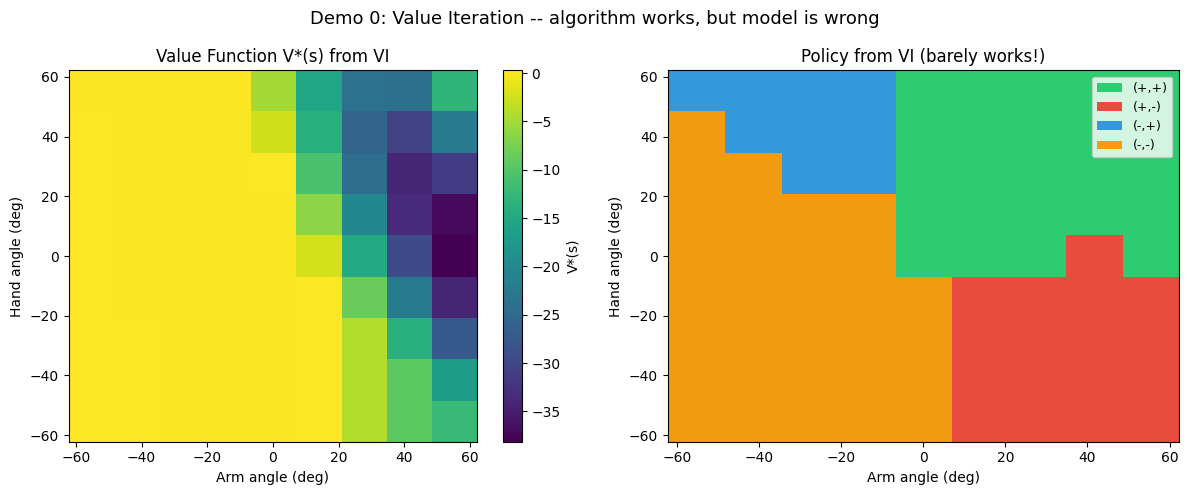

In [81]:
# Visualize VI results
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

arm_deg = np.rad2deg(angle_centers)
hand_deg = np.rad2deg(angle_centers)

# Value function heatmap
im = axes[0].imshow(V.T, origin='lower', cmap='viridis', aspect='auto',
                     extent=[arm_deg[0], arm_deg[-1], hand_deg[0], hand_deg[-1]])
axes[0].set_xlabel('Arm angle (deg)')
axes[0].set_ylabel('Hand angle (deg)')
axes[0].set_title('Value Function V*(s) from VI')
plt.colorbar(im, ax=axes[0], label='V*(s)')

# Policy map
action_labels = ['(+,+)', '(+,-)', '(-,+)', '(-,-)']  # (arm, hand) torque signs
action_colors = ['#2ecc71', '#e74c3c', '#3498db', '#f39c12']
color_map = {0: [0.18, 0.8, 0.44], 1: [0.91, 0.30, 0.24],
             2: [0.20, 0.60, 0.86], 3: [0.95, 0.61, 0.07]}
policy_img = np.zeros((N_BINS, N_BINS, 3))
for i in range(N_BINS):
    for j in range(N_BINS):
        policy_img[i, j] = color_map[pi_vi[i, j]]

axes[1].imshow(policy_img.transpose(1,0,2), origin='lower', aspect='auto',
               extent=[arm_deg[0], arm_deg[-1], hand_deg[0], hand_deg[-1]])
axes[1].set_xlabel('Arm angle (deg)')
axes[1].set_ylabel('Hand angle (deg)')
axes[1].set_title('Policy from VI (barely works!)')
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=action_colors[i], label=f'{action_labels[i]}') for i in range(4)]
axes[1].legend(handles=legend_elements, loc='upper right', fontsize=9)

plt.suptitle('Demo 0: Value Iteration -- algorithm works, but model is wrong', fontsize=13)
plt.tight_layout()
plt.show()

In [82]:
# Watch the VI policy
def vi_policy(obs):
    state = env_vi.discretize(obs, N_BINS)
    return ACTIONS_4[pi_vi[state]]

frames_vi, dist_vi, reward_vi = eval_policy(env_vi, vi_policy, 'Demo 0: Value Iteration')
show_video(frames_vi, title=f'Value Iteration Policy — {dist_vi:.2f}m in 10s (barely moves!)')

Saved rollout -> saved_rollouts/demo_0__value_iteration.npz
Demo 0: Value Iteration: traveled 0.03m in 10s  (episode reward: 1.7)


In [75]:
# Random baseline for comparison
def random_policy(obs):
    return ACTIONS_4[np.random.randint(len(ACTIONS_4))]

frames_random_vi, dist_random_vi, reward_random_vi = eval_policy(
    env_vi, random_policy, 'Demo 0: Random policy'
)
show_video(
    frames_random_vi,
    title=f'Random Policy — {dist_random_vi:.2f}m in 10s (comparison baseline)'
)

Saved rollout -> saved_rollouts/demo_0__random_policy.npz
Demo 0: Random policy: traveled 0.06m in 10s  (episode reward: 3.0)


### Interpreting Demo 0

On paper, Demo 0 looks successful: the 81-state model is built in **0.04 s**, Value Iteration itself solves in **0.012 s**, and the average evaluation reward is **1.5 +/- 0.1** versus **0.1 +/- 0.3** for a random policy. So the Bellman solver is doing its job.

But the actual behavior is still weak. The rendered VI rollout travels only **0.03 m** in 10 seconds, and the particular random rollout shown just below even goes **0.06 m**. That mismatch is a useful warning that single rollouts are noisy, but the bigger lesson is clear: solving the tabular model exactly does **not** guarantee good control if the state abstraction and transition model are poor.

So after Demo 0, the main question becomes:

> Can we keep the same Bellman-style idea, but avoid building and trusting a full tabular transition model everywhere in the state space?


### Demo 0B: Add Velocity to the State

Now rerun the **same Value Iteration pipeline**, but augment the state to

$$s = (\tilde\theta_{\mathrm{arm}}, \tilde\theta_{\mathrm{hand}}, \tilde\omega_{\mathrm{arm}}, \tilde\omega_{\mathrm{hand}}).$$

Keep the action set and reward exactly the same.

Two questions:
1. Does the rollout improve when the state now includes velocity?
2. What happens to the model-building and solve time when the state grows from $9^2$ to $9^4$ bins?


In [5]:
# ---------- Demo 0B: Value Iteration on 4D state (angles + velocities) ----------
env_vi_4d = CrawlerEnv(include_velocity=True, max_steps=500)
next_state_flat_4d, R_table_4d, build_time_4d, state_centers_4d = build_transition_model(env_vi_4d, ACTIONS_4, N_BINS)
V_4d, vi_iterations_4d, vi_time_4d, vi_delta_history_4d = run_value_iteration(next_state_flat_4d, R_table_4d, gamma=gamma)
pi_vi_4d = extract_greedy_policy(next_state_flat_4d, R_table_4d, V_4d, gamma=gamma)

print(f'  V* range: [{V_4d.min():.1f}, {V_4d.max():.1f}]')

print('\nStep 3: Evaluating VI policy on the 4D state...')
rewards_vi_eval_4d = evaluate_discrete_policy(env_vi_4d, pi_vi_4d, ACTIONS_4, N_BINS, n_trials=20)
vi_4d_total_time = build_time_4d + vi_time_4d
print(f'  VI policy (4D state): avg reward = {np.mean(rewards_vi_eval_4d):.1f} +/- {np.std(rewards_vi_eval_4d):.1f}')
print(f'  Total VI pipeline time (4D): {vi_4d_total_time:.2f}s')
print(f'  Runtime increase vs 2D state: {vi_4d_total_time / vi_total_time:.1f}x')


def vi_policy_4d(obs):
    state = env_vi_4d.discretize(obs, N_BINS)
    return ACTIONS_4[int(pi_vi_4d[state])]

frames_vi_4d, dist_vi_4d, reward_vi_4d = eval_policy(
    env_vi_4d, vi_policy_4d, 'Demo 0B: Value Iteration (4D state)'
)


Step 1: Building transition model...
  Teleporting to each of 6561 states x 4 actions = 26244 simulator calls

  Model built in 2.99s (26244 teleportation calls)

Step 2: Running Value Iteration...
  Converged in 1256 iterations (0.252s), final delta = 4.768e-07
  V* range: [-58.2, 21.4]

Step 3: Evaluating VI policy on the 4D state...
  VI policy (4D state): avg reward = 1.9 +/- 0.5
  Total VI pipeline time (4D): 3.24s
  Runtime increase vs 2D state: 67.6x
Saved rollout -> saved_rollouts/demo_0b__value_iteration__4d_state_.npz
Demo 0B: Value Iteration (4D state): traveled 0.04m in 10s  (episode reward: 1.8)


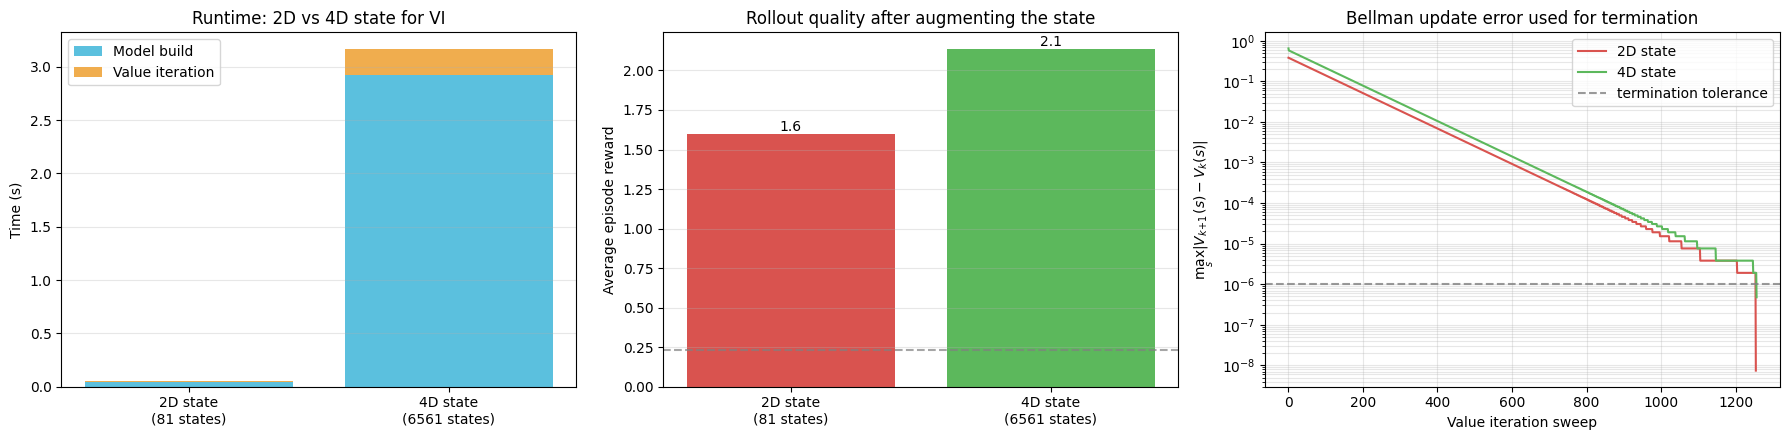

Final VI delta (2D state): 7.451e-09
Final VI delta (4D state): 4.768e-07
Termination tolerance: 1.0e-06


In [11]:
# Compare 2D vs 4D Value Iteration runtime, rollout quality, and convergence error
labels = ['2D state\n(81 states)', '4D state\n(6561 states)']
build_times = [build_time, build_time_4d]
solve_times = [vi_time, vi_time_4d]
avg_rewards = [np.mean(rewards_vi_eval), np.mean(rewards_vi_eval_4d)]
vi_tol = 1e-6

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

x = np.arange(len(labels))
axes[0].bar(x, build_times, label='Model build', color='#5bc0de')
axes[0].bar(x, solve_times, bottom=build_times, label='Value iteration', color='#f0ad4e')
axes[0].set_xticks(x, labels)
axes[0].set_ylabel('Time (s)')
axes[0].set_title('Runtime: 2D vs 4D state for VI')
axes[0].legend()
axes[0].grid(True, axis='y', alpha=0.3)

bars = axes[1].bar(labels, avg_rewards, color=['#d9534f', '#5cb85c'])
axes[1].axhline(np.mean(rewards_random), color='gray', linestyle='--', alpha=0.7)
axes[1].set_ylabel('Average episode reward')
axes[1].set_title('Rollout quality after augmenting the state')
axes[1].grid(True, axis='y', alpha=0.3)
for bar, val in zip(bars, avg_rewards):
    axes[1].text(bar.get_x() + bar.get_width()/2, val, f'{val:.1f}', ha='center', va='bottom')

axes[2].semilogy(np.arange(1, len(vi_delta_history) + 1), vi_delta_history, label='2D state', color='#d9534f')
axes[2].semilogy(np.arange(1, len(vi_delta_history_4d) + 1), vi_delta_history_4d, label='4D state', color='#5cb85c')
axes[2].axhline(vi_tol, color='gray', linestyle='--', alpha=0.8, label='termination tolerance')
axes[2].set_xlabel('Value iteration sweep')
axes[2].set_ylabel(r'$\max_s |V_{k+1}(s) - V_k(s)|$')
axes[2].set_title('Bellman update error used for termination')
axes[2].grid(True, which='both', alpha=0.3)
axes[2].legend()

plt.tight_layout()
plt.show()

print(f'Final VI delta (2D state): {vi_delta_history[-1]:.3e}')
print(f'Final VI delta (4D state): {vi_delta_history_4d[-1]:.3e}')
print(f'Termination tolerance: {vi_tol:.1e}')

show_video(frames_vi_4d, title=f'Value Iteration with 4D state — {dist_vi_4d:.2f}m in 10s')


### Interpreting Demo 0B

Adding velocity does help a little: the average evaluation reward rises from **1.5** to **1.9**, and the rendered rollout nudges from **0.03 m** to **0.04 m**. But the cost explodes: model build + solve time jumps from about **0.05 s** to **3.24 s**, a **67.6x** increase.

So the current output says something more precise than just "the 2D state was missing velocity." Richer state helps represent the physics better, but exact planning on a coarse aggregated model is still poor, and the tabular pipeline becomes much more expensive as the dimension grows.

Demo 0B therefore sharpens the diagnosis: **exact tabular planning is fragile both to model error and to state-space growth**.


### Demo 0C: Policy Iteration on the Same 4D State Space

Out of curiosity, keep the **same 4D discretized state**, **same 4 actions**, and **same transition model** from Demo 0B,
and switch only the solver from Value Iteration to **Policy Iteration**.

This isolates a different question:
- Is the bad behavior caused by the *solver* (VI vs PI)?
- Or is it mainly caused by the *discretized model* we are solving?


**Policy Iteration Reminder**

![](generated_figures/policy_iter_pd_code.png)



Running Policy Iteration...
  Improvement step  1: policy changed at 4330 states
  Improvement step  2: policy changed at 1855 states
  Improvement step  3: policy changed at 918 states
  Improvement step  4: policy changed at 367 states
  Improvement step  5: policy changed at 246 states
  Improvement step  6: policy changed at 122 states
  Improvement step  7: policy changed at 29 states
  Improvement step  8: policy changed at 4 states
  Improvement step  9: policy changed at 0 states
  Policy iteration converged in 9 improvement steps (3882 evaluation sweeps, 0.434s)
  V^pi range: [-58.2, 21.4]

Step 2: Evaluating policy-iteration policy on the 4D state...
  PI policy (4D state): avg reward = 2.0 +/- 0.6
  PI solve time only (same 4D model): 0.43s
  Final PI evaluation delta: 8.121e-07
  VI and PI choose the same action in 6560/6561 states (99.98%).
  The converged VI and PI policies differ at 1 states.
  First few differing states (bin indices):
[[6 0 2 2]]
Skipping video renderi

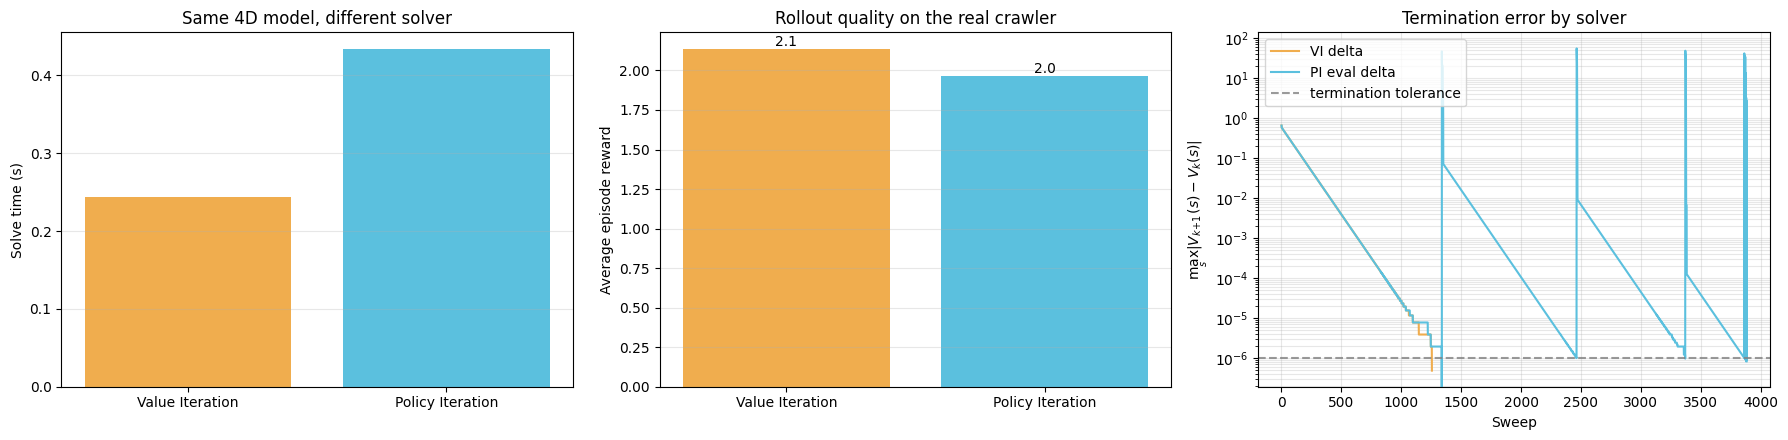

VI rollout distance (4D): 0.04m
PI rollout distance (4D): 0.04m
PI policy improvement steps: 9
PI total evaluation sweeps: 3882


In [12]:
# ---------- Demo 0C: Policy Iteration on the same 4D model ----------
pi_pi_4d, V_pi_4d, pi_improvement_steps_4d, pi_eval_sweeps_4d, pi_time_4d, pi_delta_history_4d, pi_policy_changes_4d = run_policy_iteration(
    next_state_flat_4d, R_table_4d, gamma=gamma
)

print(f'  V^pi range: [{V_pi_4d.min():.1f}, {V_pi_4d.max():.1f}]')
print('\nStep 2: Evaluating policy-iteration policy on the 4D state...')
rewards_pi_eval_4d = evaluate_discrete_policy(env_vi_4d, pi_pi_4d, ACTIONS_4, N_BINS, n_trials=20)
print(f'  PI policy (4D state): avg reward = {np.mean(rewards_pi_eval_4d):.1f} +/- {np.std(rewards_pi_eval_4d):.1f}')
print(f'  PI solve time only (same 4D model): {pi_time_4d:.2f}s')
print(f'  Final PI evaluation delta: {pi_delta_history_4d[-1]:.3e}')

same_policy_mask_4d = (pi_pi_4d == pi_vi_4d)
n_same_policy_states_4d = int(np.sum(same_policy_mask_4d))
n_total_policy_states_4d = int(pi_pi_4d.size)
n_diff_policy_states_4d = n_total_policy_states_4d - n_same_policy_states_4d
print(f'  VI and PI choose the same action in {n_same_policy_states_4d}/{n_total_policy_states_4d} states ({100*n_same_policy_states_4d/n_total_policy_states_4d:.2f}%).')
if n_diff_policy_states_4d == 0:
    print('  The converged VI and PI policies are exactly identical on the 4D discretized state space.')
else:
    print(f'  The converged VI and PI policies differ at {n_diff_policy_states_4d} states.')
    diff_states_4d = np.argwhere(~same_policy_mask_4d)
    print('  First few differing states (bin indices):')
    print(diff_states_4d[:10])


def policy_iteration_policy_4d(obs):
    state = env_vi_4d.discretize(obs, N_BINS)
    return ACTIONS_4[int(pi_pi_4d[state])]

frames_pi_4d, dist_pi_4d, reward_pi_4d = eval_policy(
    env_vi_4d, policy_iteration_policy_4d, 'Demo 0C: Policy Iteration (4D state)'
)

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

method_labels = ['Value Iteration', 'Policy Iteration']
solve_times = [vi_time_4d, pi_time_4d]
avg_rewards = [np.mean(rewards_vi_eval_4d), np.mean(rewards_pi_eval_4d)]
dists = [dist_vi_4d, dist_pi_4d]

axes[0].bar(method_labels, solve_times, color=['#f0ad4e', '#5bc0de'])
axes[0].set_ylabel('Solve time (s)')
axes[0].set_title('Same 4D model, different solver')
axes[0].grid(True, axis='y', alpha=0.3)

bars = axes[1].bar(method_labels, avg_rewards, color=['#f0ad4e', '#5bc0de'])
axes[1].set_ylabel('Average episode reward')
axes[1].set_title('Rollout quality on the real crawler')
axes[1].grid(True, axis='y', alpha=0.3)
for bar, val in zip(bars, avg_rewards):
    axes[1].text(bar.get_x() + bar.get_width()/2, val, f'{val:.1f}', ha='center', va='bottom')

axes[2].semilogy(np.arange(1, len(vi_delta_history_4d) + 1), vi_delta_history_4d, label='VI delta', color='#f0ad4e')
axes[2].semilogy(np.arange(1, len(pi_delta_history_4d) + 1), pi_delta_history_4d, label='PI eval delta', color='#5bc0de')
axes[2].axhline(vi_tol, color='gray', linestyle='--', alpha=0.8, label='termination tolerance')
axes[2].set_xlabel('Sweep')
axes[2].set_ylabel(r'$\max_s |V_{k+1}(s) - V_k(s)|$')
axes[2].set_title('Termination error by solver')
axes[2].grid(True, which='both', alpha=0.3)
axes[2].legend()

plt.tight_layout()
plt.show()

print(f'VI rollout distance (4D): {dist_vi_4d:.2f}m')
print(f'PI rollout distance (4D): {dist_pi_4d:.2f}m')
print(f'PI policy improvement steps: {pi_improvement_steps_4d}')
print(f'PI total evaluation sweeps: {pi_eval_sweeps_4d}')

show_video(frames_pi_4d, title=f'Policy Iteration with 4D state — {dist_pi_4d:.2f}m in 10s')


### Interpreting Demo 0C

This control experiment is now very strong. On the same 4D discretized model, Policy Iteration and Value Iteration choose the same action in **6560 / 6561 states (99.98%)**, and both rendered rollouts travel about **0.04 m**.

That means the failure is not primarily about VI versus PI. The solver swap changes almost nothing behaviorally, so the dominant problem is the **discretized model itself**, not which exact dynamic-programming method we run on top of it.

This matters for the bigger story of the notebook: once both exact solvers agree and both still crawl poorly, it makes little sense to spend more effort swapping one tabular planner for another. We need Bellman updates without relying on a fragile global model.


### Why Can VI / PI Converge and Still Give a Bad Policy?

The key distinction is:
- **MuJoCo is deterministic** at the continuous-state level.
- But once we lump many continuous states into one tabular bin, the induced transition model over bins is generally **not deterministic anymore**.

A single discrete bin is really a **region** of continuous states, not one point. So for the same discrete state-action pair:
- the simulator is deterministic for any one exact continuous state inside that bin
- but **different** continuous states inside that *same* bin can land in **different next bins** and produce different rewards

That means the correct tabular object is no longer “one next state per bin-action pair”, but rather a **distribution** over next bins.

Our original deterministic model in Demo 0B / 0C picks one representative point per bin, so it silently assumes:
- the whole bin behaves like that one point
- one next bin is enough to summarize the whole region

That is why VI / PI can converge numerically yet still solve the **wrong aggregated MDP**.

See the **code cell immediately below** for a concrete simulation of this effect, and see the **figures generated below that code cell** for the visual evidence that one discrete bin/action pair can fan out into multiple next bins.

That also explains why tabular Q-learning can still look better on the same discretization:
- VI / PI need a good **global model** for every state-action pair.
- Q-learning learns directly from the **real sampled trajectories** that the current policy actually visits.

Discrete 4D starting bin s: (3, 3, 3, 3)
Fixed action: a = [1. 1.] (action index 0)
Unique next bins reached from the same discrete bin/action: 8
  cluster 0: s' = (3, 3, 4, 3) -> 10/32 samples
  cluster 1: s' = (3, 3, 4, 4) -> 9/32 samples
  cluster 2: s' = (3, 3, 3, 3) -> 4/32 samples
  cluster 3: s' = (3, 2, 4, 3) -> 3/32 samples
  cluster 4: s' = (2, 3, 4, 4) -> 2/32 samples
  cluster 5: s' = (3, 3, 3, 4) -> 2/32 samples
  cluster 6: s' = (3, 2, 3, 3) -> 1/32 samples
  cluster 7: s' = (2, 3, 4, 3) -> 1/32 samples
Reward range across samples in the same bin/action: [-0.00, -0.00]


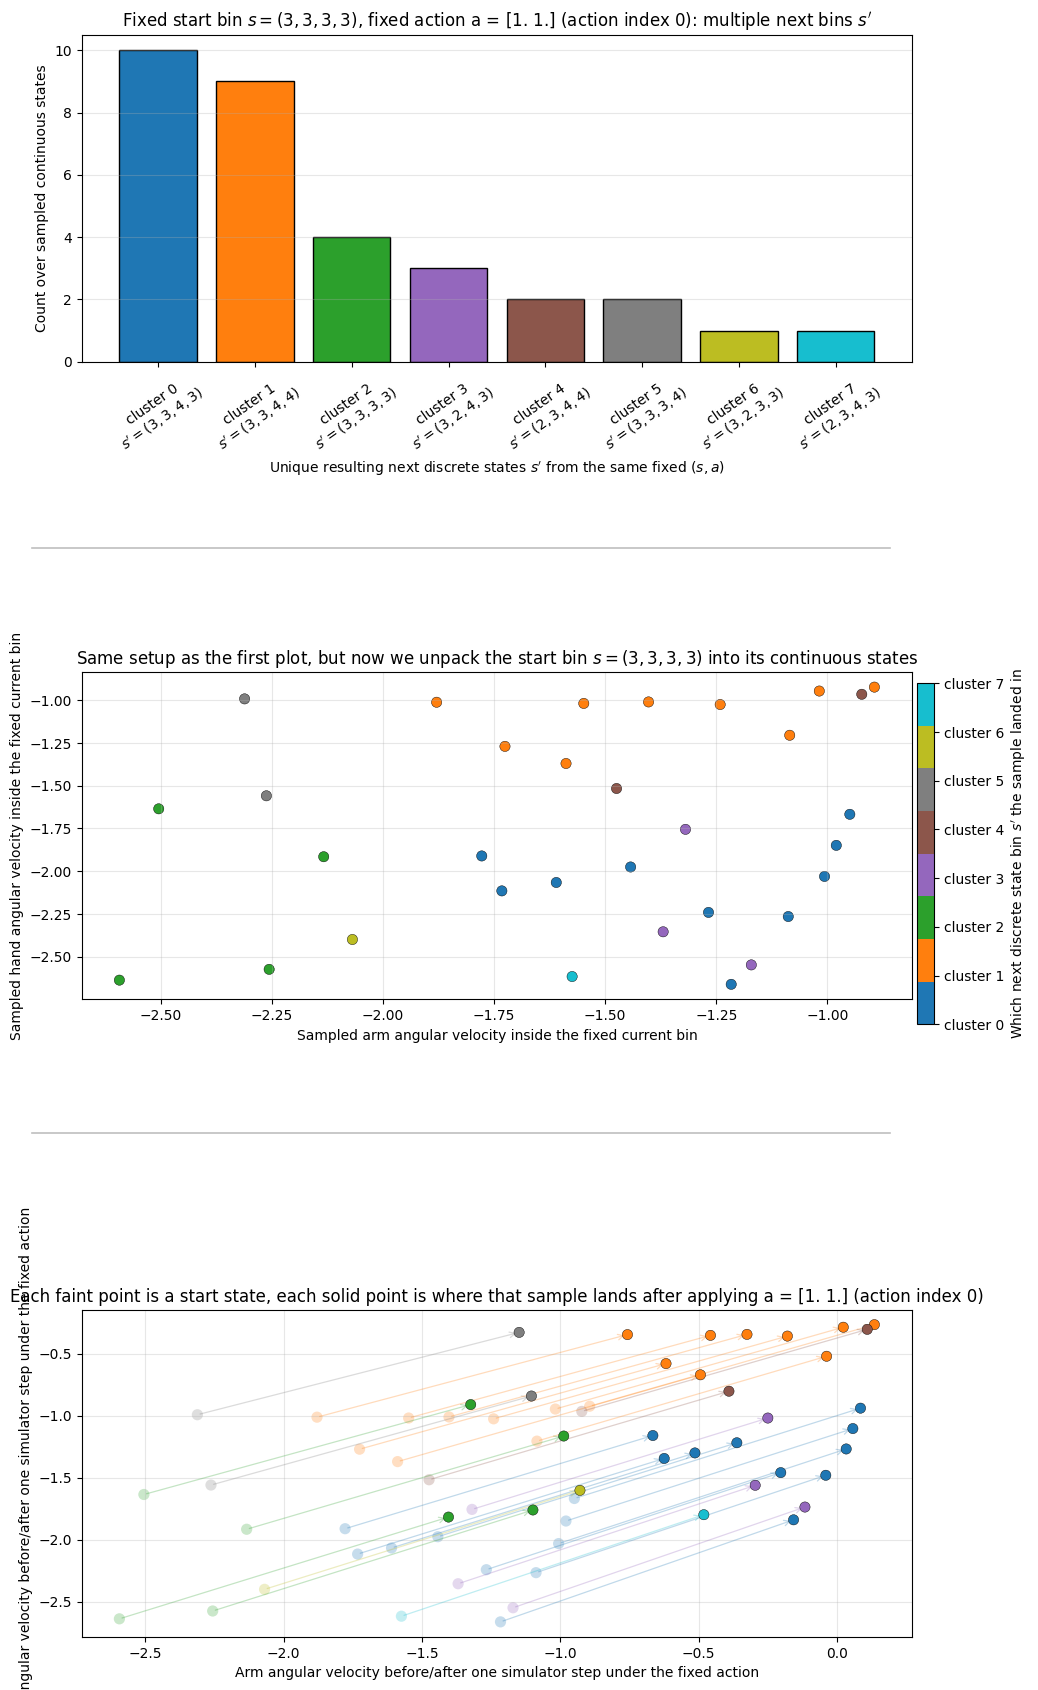

In [6]:
# ---------- Illustration: one discrete bin can map to multiple next bins ----------
uniform_edges_4d_demo = make_uniform_state_edges(env_vi_4d, N_BINS, len(env_vi_4d.reset()))
rng_demo = np.random.default_rng(0)
samples_per_demo = 32
candidate_state_indices = [
    (a0, a1, v0, v1)
    for a0 in (3, 4, 5)
    for a1 in (3, 4, 5)
    for v0 in (3, 4, 5)
    for v1 in (3, 4, 5)
]

example = None
for state_idx_demo in candidate_state_indices:
    for action_idx_demo in sorted(ACTIONS_4):
        counts = {}
        sampled_states = []
        next_bins = []
        next_obs_list = []
        rewards_demo = []
        for _ in range(samples_per_demo):
            sampled_state = sample_state_from_bin(uniform_edges_4d_demo, state_idx_demo, rng_demo)
            set_discrete_state(env_vi_4d, sampled_state)
            obs_next, reward, _, _, _ = env_vi_4d.step(ACTIONS_4[action_idx_demo])
            next_state = discretize_with_edges(obs_next, uniform_edges_4d_demo)
            counts[next_state] = counts.get(next_state, 0) + 1
            sampled_states.append(sampled_state)
            next_bins.append(next_state)
            next_obs_list.append(np.asarray(obs_next, dtype=np.float32))
            rewards_demo.append(reward)
        if len(counts) > 1:
            example = {
                'state_idx': state_idx_demo,
                'action_idx': action_idx_demo,
                'counts': counts,
                'sampled_states': np.asarray(sampled_states, dtype=np.float32),
                'next_bins': next_bins,
                'next_obs': np.asarray(next_obs_list, dtype=np.float32),
                'rewards': np.asarray(rewards_demo, dtype=np.float32),
            }
            break
    if example is not None:
        break

if example is None:
    print('Did not find a multi-next-bin example in the scanned candidate bins.')
else:
    action_value_demo = ACTIONS_4[example['action_idx']]
    state_label_demo = str(example['state_idx'])
    action_label_demo = f'a = {action_value_demo} (action index {example["action_idx"]})'

    print(f"Discrete 4D starting bin s: {state_label_demo}")
    print(f"Fixed action: {action_label_demo}")
    print(f"Unique next bins reached from the same discrete bin/action: {len(example['counts'])}")

    ordered_next_bins = [k for k, _ in sorted(example['counts'].items(), key=lambda item: item[1], reverse=True)]
    next_bin_to_cluster = {k: i for i, k in enumerate(ordered_next_bins)}
    cluster_ids = np.asarray([next_bin_to_cluster[k] for k in example['next_bins']], dtype=np.int32)
    labels = [f"cluster {next_bin_to_cluster[k]}\n$s'={k}$" for k in ordered_next_bins]
    freqs = [example['counts'][k] for k in ordered_next_bins]
    cmap = plt.get_cmap('tab10', len(ordered_next_bins))
    bar_colors = [cmap(next_bin_to_cluster[k]) for k in ordered_next_bins]

    for next_bin in ordered_next_bins:
        cid = next_bin_to_cluster[next_bin]
        print(f"  cluster {cid}: s' = {next_bin} -> {example['counts'][next_bin]}/{samples_per_demo} samples")
    print(f"Reward range across samples in the same bin/action: [{example['rewards'].min():.2f}, {example['rewards'].max():.2f}]")

    sampled_states = example['sampled_states']
    next_obs = example['next_obs']

    fig, axes = plt.subplots(3, 1, figsize=(11, 18), constrained_layout=False)

    axes[0].bar(labels, freqs, color=bar_colors, edgecolor='black')
    axes[0].set_xlabel("Unique resulting next discrete states $s'$ from the same fixed $(s, a)$")
    axes[0].set_ylabel('Count over sampled continuous states')
    axes[0].set_title(f"Fixed start bin $s={state_label_demo}$, fixed action {action_label_demo}: multiple next bins $s'$")
    axes[0].tick_params(axis='x', rotation=35)
    axes[0].grid(True, axis='y', alpha=0.3)

    axes[1].scatter(sampled_states[:, 2], sampled_states[:, 3], c=cluster_ids, cmap=cmap, s=55, edgecolor='black', linewidth=0.3)
    axes[1].set_xlabel('Sampled arm angular velocity inside the fixed current bin')
    axes[1].set_ylabel('Sampled hand angular velocity inside the fixed current bin')
    axes[1].set_title(f"Same setup as the first plot, but now we unpack the start bin $s={state_label_demo}$ into its continuous states")
    axes[1].grid(True, alpha=0.3)

    start_colors = [cmap(cid) for cid in cluster_ids]
    axes[2].scatter(
        sampled_states[:, 2],
        sampled_states[:, 3],
        c=start_colors,
        s=65,
        alpha=0.25,
        edgecolor='none',
        zorder=1,
    )
    for i in range(len(sampled_states)):
        axes[2].annotate(
            '',
            xy=(next_obs[i, 2], next_obs[i, 3]),
            xytext=(sampled_states[i, 2], sampled_states[i, 3]),
            arrowprops=dict(arrowstyle='->', color=cmap(cluster_ids[i]), alpha=0.28, lw=0.9),
            zorder=2,
        )
    sc2 = axes[2].scatter(next_obs[:, 2], next_obs[:, 3], c=cluster_ids, cmap=cmap, s=55, edgecolor='black', linewidth=0.3, zorder=3)
    axes[2].set_xlabel('Arm angular velocity before/after one simulator step under the fixed action')
    axes[2].set_ylabel('Hand angular velocity before/after one simulator step under the fixed action')
    axes[2].set_title(f"Each faint point is a start state, each solid point is where that sample lands after applying {action_label_demo}")
    axes[2].grid(True, alpha=0.3)

    cbar = plt.colorbar(sc2, ax=axes, fraction=0.02, pad=0.015)
    cbar.set_ticks(np.arange(len(ordered_next_bins)))
    cbar.set_ticklabels([f"cluster {i}" for i in range(len(ordered_next_bins))])
    cbar.set_label("Which next discrete state bin $s'$ the sample landed in")

    fig.subplots_adjust(hspace=0.95, right=0.88, top=0.95, bottom=0.06)
    for y in (0.665, 0.34):
        fig.add_artist(plt.Line2D([0.08, 0.86], [y, y], transform=fig.transFigure, color='0.75', linewidth=1.2))
    plt.show()


---
## Demo 1A: Tabular Q-learning works on coarse discrete states

**Setup at a glance**

| Quantity | Notation | In this demo |
|---|---|---|
| State | $s = (\tilde\theta_{\mathrm{arm}}, \tilde\theta_{\mathrm{hand}})$ | Same 2D **discrete** angle state as Demo 0, with 9 bins per joint $\Rightarrow 81$ states |
| Action | $a \in \mathcal{A}$ | Same 4 **discrete** torque commands: $\{(+,+), (+,-), (-,+), (-,-)\}$ |
| Reward | $r_t$ | $$r_t = \frac{x_{t+1} - x_t}{\Delta t}$$ |
| Exploration schedule | $\epsilon_k$ | Start with `eps_start = 1.0`, then decay each episode as $\epsilon \leftarrow \max(0.01, 0.995\,\epsilon)$ |
| Learning rate | $\alpha$ | Fixed constant: `lr = 0.1` (no decay schedule in this demo) |

The Q-table is tiny: **81 × 4 = 324 entries**. Q-learning should fill this in quickly.

**Algorithm reminder**

![](generated_figures/tabular_q_learning_pd_code.png)


In [10]:
# ============================================================
# Tabular Q-Learning
# ============================================================

def train_tabular_q(env, action_map, n_bins=9, n_episodes=2000,
                    lr=0.1, gamma=0.99, eps_start=1.0, eps_end=0.01,
                    eps_decay=0.995, verbose=True, reward_fn=None,
                    checkpoint_label=None, checkpoint_meta=None):
    """Train tabular Q-learning. Returns Q-table and reward history."""
    n_actions = len(action_map)

    # Determine Q-table shape from observation dimensionality
    test_obs = env.reset()
    test_state = env.discretize(test_obs, n_bins)
    q_shape = (n_bins,) * len(test_state) + (n_actions,)

    Q = np.zeros(q_shape)
    visit_count = np.zeros(q_shape[:-1], dtype=np.int32)  # track visits
    epsilon = eps_start
    rewards = []

    def save_checkpoint(interrupted=False):
        if checkpoint_label is None:
            return
        meta = {
            'n_bins': int(n_bins),
            'obs_dim': len(test_state),
            'n_actions': n_actions,
            'action_signature': action_map_signature(action_map),
            'interrupted': bool(interrupted),
            'episodes_completed': len(rewards),
        }
        if checkpoint_meta:
            meta.update(checkpoint_meta)
        save_latest_checkpoint({
            'kind': 'tabular_q',
            'label': checkpoint_label,
            'meta': meta,
            'Q': Q,
            'visit_count': visit_count,
            'rewards': np.asarray(rewards, dtype=np.float32),
        })

    t0 = time.time()
    try:
        for ep in range(n_episodes):
            obs = env.reset()
            state = env.discretize(obs, n_bins)
            total_reward = 0

            while True:
                # Epsilon-greedy action selection
                if np.random.random() < epsilon:
                    action = np.random.randint(n_actions)
                else:
                    action = np.argmax(Q[state])

                obs, reward, terminated, truncated, info = env.step(action_map[action])
                next_state = env.discretize(obs, n_bins)
                done = terminated or truncated
                shaped_reward = reward_fn(reward, terminated, truncated, info, env) if reward_fn is not None else reward

                # Q-learning update
                best_next = np.max(Q[next_state]) if not terminated else 0
                td_target = shaped_reward + gamma * best_next
                Q[state + (action,)] += lr * (td_target - Q[state + (action,)])

                visit_count[state] += 1
                state = next_state
                total_reward += shaped_reward

                if done:
                    break

            epsilon = max(eps_end, epsilon * eps_decay)
            rewards.append(total_reward)

            if verbose and (ep + 1) % 500 == 0:
                avg = np.mean(rewards[-100:])
                pct_visited = np.mean(visit_count > 0) * 100
                print(f'  Episode {ep+1:5d} | Avg reward: {avg:7.1f} | '
                      f'States visited: {pct_visited:.0f}% | eps: {epsilon:.3f}')
    except KeyboardInterrupt:
        save_checkpoint(interrupted=True)
        print(f'  Training interrupted after {len(rewards)} episodes; checkpoint saved.')
        raise

    elapsed = time.time() - t0
    if verbose:
        print(f'  Training completed in {elapsed:.1f}s')
        print(f'  Q-table shape: {Q.shape} ({Q.size} entries)')
        print(f'  States visited at least once: {np.mean(visit_count > 0)*100:.0f}%')

    save_checkpoint(interrupted=False)

    return Q, visit_count, rewards

In [11]:
# ---------- Demo 1A: Tabular Q-learning on 2D state ----------
N_BINS = 9

print('=== Demo 1A: Tabular Q-learning with 2D state (angles only) ===')
print(f'State space: {N_BINS}x{N_BINS} = {N_BINS**2} states')
print(f'Action space: 4 discrete actions')
print(f'Q-table size: {N_BINS**2 * 4} entries\n')

env_2d = CrawlerEnv(include_velocity=False, max_steps=500)

latest = maybe_load_latest_tabular(
    n_bins=N_BINS,
    obs_dim=len(env_2d.discretize(env_2d.reset(), N_BINS)),
    action_map=ACTIONS_4,
    label='Demo 1A: Tabular Q-learning (2D)',
    extra_meta={'demo': '1A', 'variant': 'tabular_2d_speed'},
)
# latest = None
if latest is None:
    Q_2d, visits_2d, rewards_2d = train_tabular_q(
        env_2d, ACTIONS_4, n_bins=N_BINS, n_episodes=1000,
        checkpoint_label='Demo 1A: Tabular Q-learning (2D)',
        checkpoint_meta={'demo': '1A', 'variant': 'tabular_2d_speed'}
    )
else:
    Q_2d, visits_2d, rewards_2d = latest

# TODO plot time here

=== Demo 1A: Tabular Q-learning with 2D state (angles only) ===
State space: 9x9 = 81 states
Action space: 4 discrete actions
Q-table size: 324 entries

Loaded checkpoint for Demo 1A: Tabular Q-learning (2D); skipping retraining.
  path: saved_checkpoints/tabular_q_1A_tabular_2d_speed_2_9_4.pt


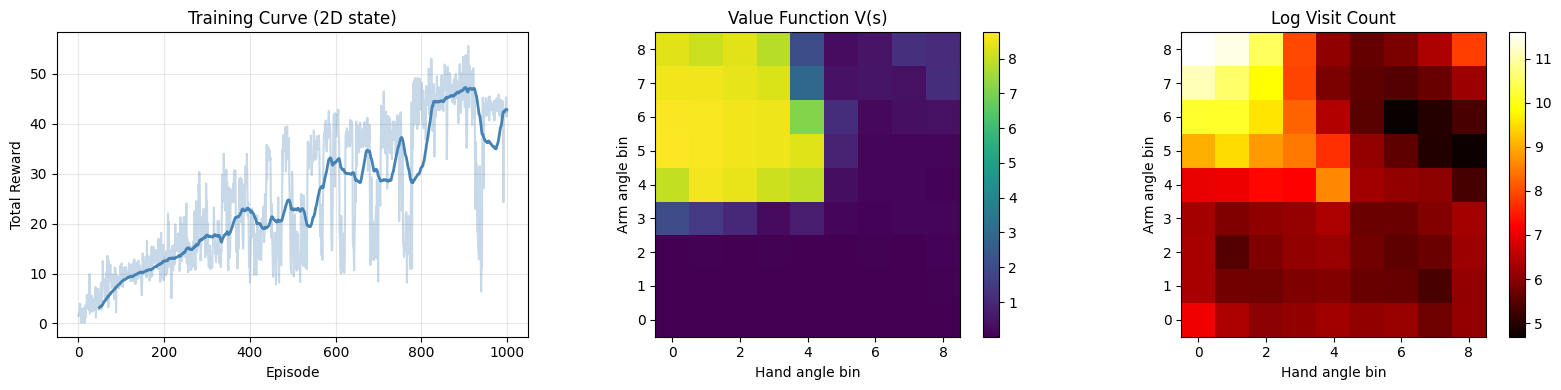

/var/folders/sz/1j1qn1v96gs82h7ywn4p48q40000gn/T/ipykernel_82924/168454257.py:31: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('coolwarm')


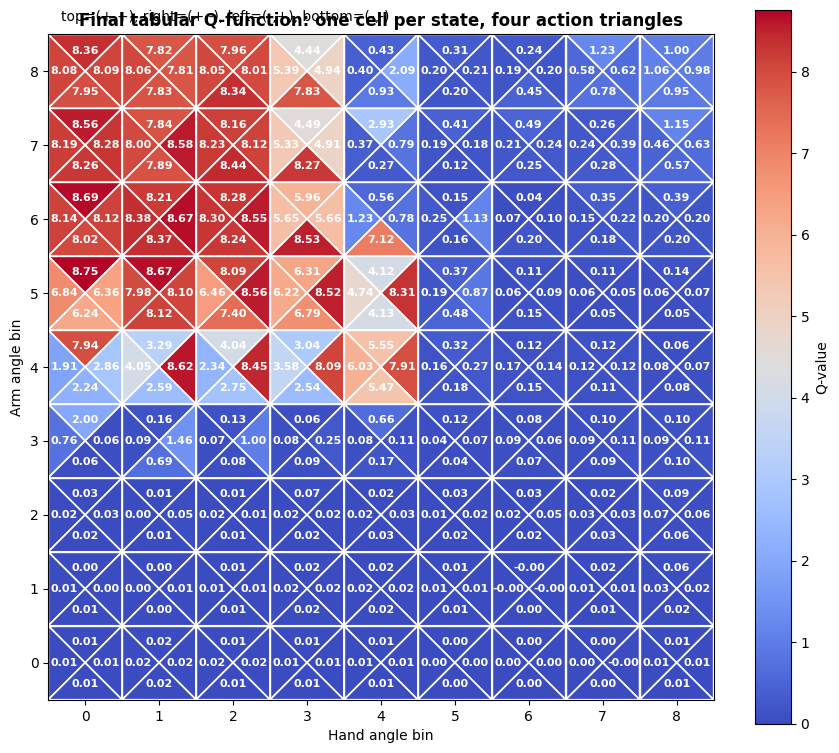

In [12]:
# Visualize the Q-table and training curve
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Training curve
plot_rewards(rewards_2d, title='Training Curve (2D state)', ax=axes[0])

# Value function: V(s) = max_a Q(s, a)
V_2d = Q_2d.max(axis=-1)
im = axes[1].imshow(V_2d, origin='lower', cmap='viridis', aspect='equal')
axes[1].set_xlabel('Hand angle bin')
axes[1].set_ylabel('Arm angle bin')
axes[1].set_title('Value Function V(s)')
plt.colorbar(im, ax=axes[1])

# Visit counts
im2 = axes[2].imshow(np.log1p(visits_2d), origin='lower', cmap='hot', aspect='equal')
axes[2].set_xlabel('Hand angle bin')
axes[2].set_ylabel('Arm angle bin')
axes[2].set_title('Log Visit Count')
plt.colorbar(im2, ax=axes[2])

plt.tight_layout()
plt.show()

# Composite Q-table: each state cell is split into four action triangles
from matplotlib.patches import Polygon
from matplotlib import cm, colors

fig, ax = plt.subplots(figsize=(9, 9))
norm = colors.Normalize(vmin=Q_2d.min(), vmax=Q_2d.max())
cmap = cm.get_cmap('coolwarm')

for i in range(N_BINS):
    for j in range(N_BINS):
        x0, y0 = j, i
        xc, yc = x0 + 0.5, y0 + 0.5
        corners = {
            'bl': (x0, y0),
            'br': (x0 + 1, y0),
            'tr': (x0 + 1, y0 + 1),
            'tl': (x0, y0 + 1),
        }
        # action 0=(+,+): top, 1=(+,-): right, 2=(-,+): left, 3=(-,-): bottom
        triangles = {
            0: [corners['tl'], corners['tr'], (xc, yc)],
            1: [corners['br'], corners['tr'], (xc, yc)],
            2: [corners['bl'], corners['tl'], (xc, yc)],
            3: [corners['bl'], corners['br'], (xc, yc)],
        }
        text_pos = {
            0: (xc, y0 + 0.78),
            1: (x0 + 0.78, yc),
            2: (x0 + 0.22, yc),
            3: (xc, y0 + 0.22),
        }
        for a in range(4):
            q = Q_2d[i, j, a]
            patch = Polygon(triangles[a], closed=True, facecolor=cmap(norm(q)), edgecolor='white', linewidth=1.2)
            ax.add_patch(patch)
            tx, ty = text_pos[a]
            ax.text(tx, ty, f'{q:.2f}', ha='center', va='center', color='white', fontsize=8, fontweight='bold')

for k in range(N_BINS + 1):
    ax.plot([0, N_BINS], [k, k], color='white', lw=1.0)
    ax.plot([k, k], [0, N_BINS], color='white', lw=1.0)

ax.set_xlim(0, N_BINS)
ax.set_ylim(0, N_BINS)
ax.set_aspect('equal')
ax.set_xticks(np.arange(N_BINS) + 0.5)
ax.set_yticks(np.arange(N_BINS) + 0.5)
ax.set_xticklabels(range(N_BINS))
ax.set_yticklabels(range(N_BINS))
ax.set_xlabel('Hand angle bin')
ax.set_ylabel('Arm angle bin')
ax.set_title('Final tabular Q-function: one cell per state, four action triangles', fontweight='bold')

sm = cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, shrink=0.82)
cbar.set_label('Q-value')

ax.text(0.02, 1.02, 'top=(+,+), right=(+,-), left=(-,+), bottom=(-,-)', transform=ax.transAxes, fontsize=10)
plt.tight_layout()
plt.show()

In [13]:
# Watch the learned policy!
def q_policy_2d(obs):
    state = env_2d.discretize(obs, N_BINS)
    action = np.argmax(Q_2d[state])
    return ACTIONS_4[action]

frames_2d, dist_2d, _ = eval_policy(env_2d, q_policy_2d, 'Demo 1A: Tabular Q (2D, speed reward)')
show_video(frames_2d, title=f'Tabular Q-learning 1A: 2D state — {dist_2d:.2f}m in 10s (works!)')

Saved rollout -> saved_rollouts/demo_1a__tabular_q__2d__speed_reward_.npz
Demo 1A: Tabular Q (2D, speed reward): traveled 0.87m in 10s  (episode reward: 43.4)


### Why can Q-learning work better than Value Iteration here?

At first sight this can feel surprising. After all, tabular Q-learning is still doing Bellman-style updates on the **same discretized state space**. And after every simulator step, we still quantize the continuous observation back into bins before updating the Q-table.

So Q-learning is **not** winning because it avoids discretization. Both methods discretize.

The more important difference is **how the transition between bins is defined and used**.

For **Value Iteration**, we need an explicit transition model for every discrete state-action pair $(s,a)$:
- start from bin $s$
- somehow choose or construct a concrete continuous state inside that bin
- apply action $a$
- simulate one step
- quantize the result back to a new bin $s'$
- store that transition in the model

But a bin is not a single physical state. It is a **whole set of continuous states**. Many different continuous states can fall into the same bin, and they may react differently to the same action. So when we build the model, we are forced to represent all of that complicated behavior with one coarse transition description. That is where the distortion starts.

For **Q-learning**, we never ask: *what is the transition out of bin $s$ in general?*
Instead, we ask: *during this actual rollout, I happened to be in some real continuous state that maps to bin $s$; after taking action $a$, what happened next?*

Then we update the Q-table from that one sampled transition.

So the key difference is:
- **Value Iteration** needs one explicit answer for every discretized $(s,a)$ pair everywhere in the state space
- **Q-learning** can learn from many sampled transitions that arise from the real continuous simulator during actual trajectories

This matters a lot because each bin hides many different continuous "microstates". If those microstates are heterogeneous, then:
- Value Iteration has to compress them into one model transition structure
- Q-learning can learn an empirical average over the microstates that are actually encountered during rollouts

Another important point: **Demo 0B already showed that just adding velocity does not automatically fix Value Iteration.** So the problem is not only that Demo 0A was missing velocity. Even with a richer state, the explicit discretized model can still be too crude for the true continuous, contact-rich crawler dynamics.

So the lesson is not:

> "Q-learning works because it keeps the true continuous state while Value Iteration does not."

That would be wrong. Q-learning also maps the continuous simulator state back into bins at every step.

A better summary is:

> "Value Iteration needs a global tabular transition model between bins. Q-learning uses the same bins, but learns from sampled transitions generated by real rollouts in the true simulator. When the tabular model is poor, approximate learning from real experience can beat exact planning on the wrong model."


### Small Sensitivity Check: exploration $\epsilon$ and learning rate $\alpha$

Before moving on, let's do a **very rough** parameter sweep around Demo 1A.
We will only vary two knobs:
- $\epsilon$: the epsilon-greedy exploration probability at the start of training
- $\alpha$: the Q-learning update step size

To keep runtime reasonable, each setting is trained for only **500 episodes** and we use just a **coarse grid**. So this is not meant to find the best hyperparameters, only to show that performance can change noticeably when these values change.


In [ ]:
# ---------- Demo 1A extra: small sensitivity sweep over epsilon and alpha ----------
eps_grid = [0.1, 0.4, 1.0]
alpha_grid = [0.03, 0.1, 0.3]
sweep_results = []

print('=== Demo 1A extra: coarse epsilon/alpha sensitivity ===')
print('Each run uses only 500 episodes, so treat this as a rough trend check.\n')

for alpha in alpha_grid:
    for eps0 in eps_grid:
        env_sweep = CrawlerEnv(include_velocity=False, max_steps=500)
        Q_sweep, _, rewards_sweep = train_tabular_q(
            env_sweep, ACTIONS_4, n_bins=N_BINS, n_episodes=500,
            lr=alpha, eps_start=eps0, eps_end=0.01, eps_decay=0.995,
            verbose=False
        )

        def q_policy_sweep(obs, Q_local=Q_sweep, env_local=env_sweep):
            state = env_local.discretize(obs, N_BINS)
            action = np.argmax(Q_local[state])
            return ACTIONS_4[action]

        _, dist_sweep, _ = eval_policy(
            env_sweep, q_policy_sweep,
            f'Sensitivity sweep: eps={eps0}, alpha={alpha}'
        )
        avg_last100 = float(np.mean(rewards_sweep[-100:]))
        sweep_results.append({
            'eps0': eps0,
            'alpha': alpha,
            'avg_last100': avg_last100,
            'distance_10s': dist_sweep,
        })
        print(f'eps0={eps0:>4.2f}, alpha={alpha:>4.2f} -> avg(last100)={avg_last100:>6.2f}, rollout distance={dist_sweep:>5.2f} m')

avg_reward_grid = np.zeros((len(alpha_grid), len(eps_grid)))
distance_grid = np.zeros((len(alpha_grid), len(eps_grid)))
for r in sweep_results:
    i = alpha_grid.index(r['alpha'])
    j = eps_grid.index(r['eps0'])
    avg_reward_grid[i, j] = r['avg_last100']
    distance_grid[i, j] = r['distance_10s']

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

im0 = axes[0].imshow(avg_reward_grid, cmap='YlGnBu', aspect='auto')
axes[0].set_title('Avg training reward\n(last 100 episodes)')
axes[0].set_xlabel('initial epsilon')
axes[0].set_ylabel('alpha (learning rate)')
axes[0].set_xticks(range(len(eps_grid)))
axes[0].set_xticklabels([f'{v:.2f}' for v in eps_grid])
axes[0].set_yticks(range(len(alpha_grid)))
axes[0].set_yticklabels([f'{v:.2f}' for v in alpha_grid])
for i in range(len(alpha_grid)):
    for j in range(len(eps_grid)):
        axes[0].text(j, i, f'{avg_reward_grid[i, j]:.1f}', ha='center', va='center', color='black')
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(distance_grid, cmap='OrRd', aspect='auto')
axes[1].set_title('Greedy policy distance in 10s')
axes[1].set_xlabel('initial epsilon')
axes[1].set_ylabel('alpha (learning rate)')
axes[1].set_xticks(range(len(eps_grid)))
axes[1].set_xticklabels([f'{v:.2f}' for v in eps_grid])
axes[1].set_yticks(range(len(alpha_grid)))
axes[1].set_yticklabels([f'{v:.2f}' for v in alpha_grid])
for i in range(len(alpha_grid)):
    for j in range(len(eps_grid)):
        axes[1].text(j, i, f'{distance_grid[i, j]:.2f}m', ha='center', va='center', color='black')
plt.colorbar(im1, ax=axes[1])

plt.tight_layout()
plt.show()

best_by_distance = max(sweep_results, key=lambda r: r['distance_10s'])
worst_by_distance = min(sweep_results, key=lambda r: r['distance_10s'])
print('\nTakeaway: even in this tiny tabular problem, too little exploration or a poor learning rate can noticeably hurt performance.')
print(f"Best rollout in this coarse sweep: eps0={best_by_distance['eps0']:.2f}, alpha={best_by_distance['alpha']:.2f}, distance={best_by_distance['distance_10s']:.2f}m")
print(f"Worst rollout in this coarse sweep: eps0={worst_by_distance['eps0']:.2f}, alpha={worst_by_distance['alpha']:.2f}, distance={worst_by_distance['distance_10s']:.2f}m")


=== Demo 1A extra: coarse epsilon/alpha sensitivity ===
Each run uses only 500 episodes, so treat this as a rough trend check.

Saved rollout -> saved_rollouts/sensitivity_sweep__eps_0.1__alpha_0.03.npz
Sensitivity sweep: eps=0.1, alpha=0.03: traveled 0.60m in 10s  (episode reward: 30.1)
eps0=0.10, alpha=0.03 -> avg(last100)= 25.67, rollout distance= 0.60 m
Saved rollout -> saved_rollouts/sensitivity_sweep__eps_0.4__alpha_0.03.npz
Sensitivity sweep: eps=0.4, alpha=0.03: traveled 0.61m in 10s  (episode reward: 30.4)
eps0=0.40, alpha=0.03 -> avg(last100)= 25.90, rollout distance= 0.61 m


### Interpreting the Sensitivity Check

The currently saved sweep output is only a rough **500-episode** check, but it already makes the point. Even two nearby settings with the same learning rate (`alpha=0.03`) land at only about **0.60-0.61 m** after 10 seconds.

That is still useful behavior, but it is noticeably below the main Demo 1A run at **0.87 m**. So tabular Q-learning on the tiny 81-state problem is not hyperparameter-free: exploration schedule, step size, and training budget all matter.

Still, the bigger picture remains encouraging. Even with rough tuning, model-free Q-learning can learn a useful policy on this coarse discrete problem, whereas the exact planning pipeline in Demo 0 was much more brittle to the modeling assumptions.


### Demo 1B: Same 2D Q-learning, but a different reward

Keep the **same 2D state** and **same 4 actions**, but change the training reward.

Instead of rewarding **instantaneous forward speed** at every step,
train with a sparse episode objective that only rewards the **final distance covered after 10s**:

$$
r_t^{\text{dist}} =
\begin{cases}
0 & t < T, \\
 x_T & t = T,
\end{cases}
$$

where $x_T$ is the final torso position at the end of the 10-second rollout.

Pseudocode for the reward computation used in training:

```python
x_start = torso_x_position()
for t in range(T):
    take_action(a_t)
    step_simulator()
    reward = 0

# only at the very end of the episode
x_final = torso_x_position()
reward = x_final - x_start
```

In this notebook the crawler starts near `x=0`, so this is effectively the same as using the final torso position `x_T` as the terminal reward.

So Demo 1A and 1B differ only in the reward used during training:
- Demo 1A: maximize forward **speed** step by step
- Demo 1B: maximize final **distance** after 10s

This lets us test how sensitive tabular Q-learning is to reward design, even when the state and action spaces stay tiny.


=== Demo 1B: Tabular Q-learning with 2D state (terminal distance reward) ===
State space: 9x9 = 81 states
Same 4 actions, but now the reward is final distance after 10s only.

  Episode   500 | Avg reward:     0.2 | States visited: 100% | eps: 0.082
  Episode  1000 | Avg reward:     0.2 | States visited: 100% | eps: 0.010
  Training completed in 24.4s
  Q-table shape: (9, 9, 4) (324 entries)
  States visited at least once: 100%
Saved checkpoint -> saved_checkpoints/tabular_q_1B_tabular_2d_final_distance_2_9_4.pt
Saved rollout -> saved_rollouts/demo_1b__tabular_q__2d__terminal_distance_reward_.npz
Demo 1B: Tabular Q (2D, terminal distance reward): traveled 0.21m in 10s  (episode reward: 10.3)


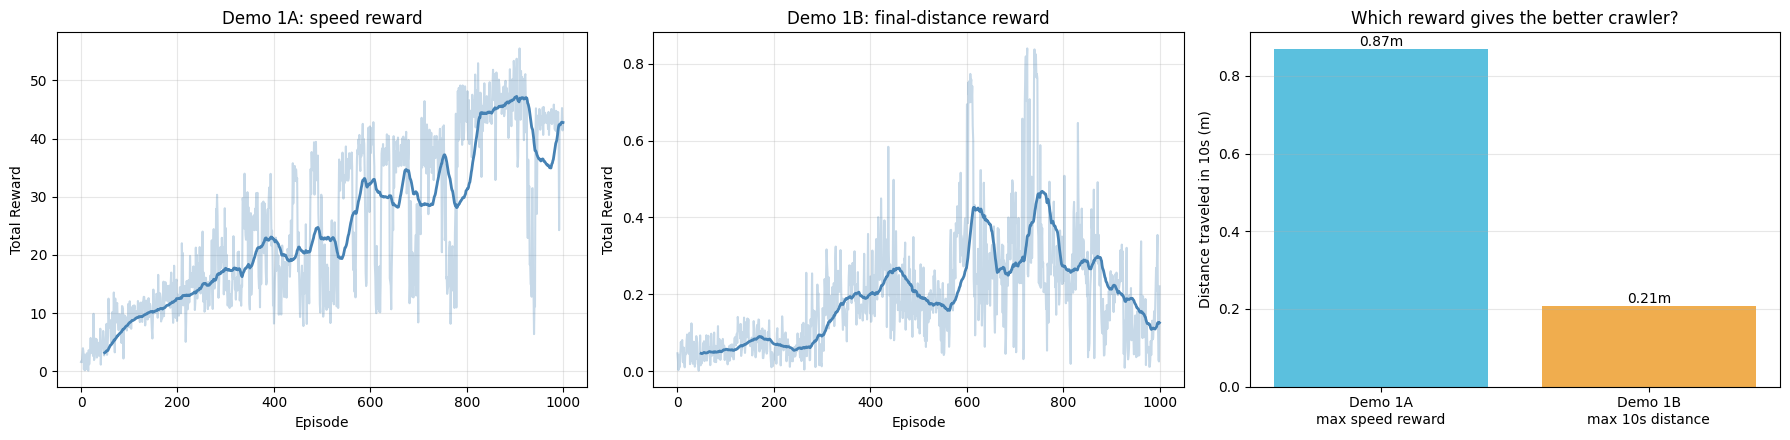

Demo 1A rollout distance (speed reward): 0.87m
Demo 1B rollout distance (final-distance reward): 0.21m
Demo 1A episode reward under its own training objective: 39.6
Demo 1B episode reward under its own training objective: 0.151


In [15]:
# ---------- Demo 1B: Tabular Q-learning on 2D state with terminal-distance reward ----------
def reward_final_distance_10s(reward, terminated, truncated, info, env):
    done = terminated or truncated
    return float(info['x']) if done else 0.0

print('=== Demo 1B: Tabular Q-learning with 2D state (terminal distance reward) ===')
print(f'State space: {N_BINS}x{N_BINS} = {N_BINS**2} states')
print('Same 4 actions, but now the reward is final distance after 10s only.\n')

env_2d_dist = CrawlerEnv(include_velocity=False, max_steps=500)

latest = maybe_load_latest_tabular(
    n_bins=N_BINS,
    obs_dim=len(env_2d_dist.discretize(env_2d_dist.reset(), N_BINS)),
    action_map=ACTIONS_4,
    label='Demo 1B: Tabular Q-learning (2D, terminal distance reward)',
    extra_meta={'demo': '1B', 'variant': 'tabular_2d_final_distance'},
)
# latest = None
if latest is None:
    Q_2d_dist, visits_2d_dist, rewards_2d_dist = train_tabular_q(
        env_2d_dist, ACTIONS_4, n_bins=N_BINS, n_episodes=1000,
        reward_fn=reward_final_distance_10s,
        checkpoint_label='Demo 1B: Tabular Q-learning (2D, terminal distance reward)',
        checkpoint_meta={'demo': '1B', 'variant': 'tabular_2d_final_distance'}
    )
else:
    Q_2d_dist, visits_2d_dist, rewards_2d_dist = latest


def q_policy_2d_dist(obs):
    state = env_2d_dist.discretize(obs, N_BINS)
    action = np.argmax(Q_2d_dist[state])
    return ACTIONS_4[action]

frames_2d_dist, dist_2d_dist, reward_2d_dist = eval_policy(
    env_2d_dist, q_policy_2d_dist, 'Demo 1B: Tabular Q (2D, terminal distance reward)'
)

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
plot_rewards(rewards_2d, title='Demo 1A: speed reward', ax=axes[0])
plot_rewards(rewards_2d_dist, title='Demo 1B: final-distance reward', ax=axes[1])

method_labels = ['Demo 1A\nmax speed reward', 'Demo 1B\nmax 10s distance']
rollout_distances = [dist_2d, dist_2d_dist]
bars = axes[2].bar(method_labels, rollout_distances, color=['#5bc0de', '#f0ad4e'])
axes[2].set_ylabel('Distance traveled in 10s (m)')
axes[2].set_title('Which reward gives the better crawler?')
axes[2].grid(True, axis='y', alpha=0.3)
for bar, val in zip(bars, rollout_distances):
    axes[2].text(bar.get_x() + bar.get_width()/2, val, f'{val:.2f}m', ha='center', va='bottom')

plt.tight_layout()
plt.show()

print(f'Demo 1A rollout distance (speed reward): {dist_2d:.2f}m')
print(f'Demo 1B rollout distance (final-distance reward): {dist_2d_dist:.2f}m')
print(f'Demo 1A episode reward under its own training objective: {np.mean(rewards_2d[-100:]):.1f}')
print(f'Demo 1B episode reward under its own training objective: {np.mean(rewards_2d_dist[-100:]):.3f}')
show_video(frames_2d_dist, title=f'Demo 1B: terminal-distance reward — {dist_2d_dist:.2f}m in 10s')


### Interpreting Demo 1B

The current output makes the lesson sharper than just "reward matters." Demo 1B uses a reward that sounds more directly aligned with the goal -- final distance after 10s -- but it learns a much worse controller: the greedy rollout travels only about **0.21 m**, compared with about **0.87 m** for Demo 1A.

Why? Because the final-distance reward is much **sparser** and more **delayed**. For almost the entire episode the agent sees reward 0, and only at the end gets one scalar telling it how the whole 10-second rollout went. Q-learning can in principle propagate that signal backward, but with long episodes and a coarse tabular state, credit assignment becomes much harder than with the dense speed reward used in Demo 1A.

So Demo 1B shows that reward design is not only about matching the objective conceptually; it is also about making the learning problem numerically tractable. A denser shaping reward can be easier to optimize and can even produce better final behavior than a sparser, seemingly more direct objective. Also, the raw training rewards of Demo 1A and Demo 1B are on different scales, so the fair comparison is the shared evaluation metric: **distance traveled in 10s**.


---
## Demo 2: Tabular Q-learning **breaks** with richer state

**Setup at a glance**

| Quantity | Notation | In this demo |
|---|---|---|
| State | $s = (\tilde\theta_{\mathrm{arm}}, \tilde\theta_{\mathrm{hand}}, \tilde\omega_{\mathrm{arm}}, \tilde\omega_{\mathrm{hand}})$ | 4D **discrete** state: angle bins plus velocity bins, 9 bins each $\Rightarrow 9^4 = 6{,}561$ states |
| Action | $a \in \mathcal{A}$ | Same 4 **discrete** torque commands: $\{(+,+), (+,-), (-,+), (-,-)\}$ |
| Reward | $r_t$ | $$r_t = \frac{x_{t+1} - x_t}{\Delta t}$$ |

To control the crawler well, we should also know **how fast** the joints are moving — not just where they are.

With 9 bins per dimension, the Q-table has **6,561 × 4 = 26,244 entries**.

**Same algorithm, same update:**

$$Q(s_t,a_t) \leftarrow Q(s_t,a_t) + \alpha\left[r_t + \gamma \max_{a'} Q(s_{t+1}, a') - Q(s_t,a_t)\right]$$

**Algorithm**
Same tabular Q-learning algorithm as Demo 1A:

Start with $Q_0(s,a)$ for all $s, a$.

Get initial state $s$.

For $k = 1, 2, \ldots$ till convergence:

Sample action $a$, get next state $s'$.

If $s'$ is terminal:

$$\mathrm{target} = R(s,a,s')$$

Else:

$$\mathrm{target} = R(s,a,s') + \gamma \max_{a'} Q_k(s', a')$$

$$Q_{k+1}(s,a) \leftarrow (1-\alpha)Q_k(s,a) + \alpha\,[\mathrm{target}]$$

$$s \leftarrow s'$$

Only the state definition changed: we now discretize $(\theta_{\mathrm{arm}}, \theta_{\mathrm{hand}}, \omega_{\mathrm{arm}}, \omega_{\mathrm{hand}})$ instead of just the two angles.

Sounds manageable? Let's see...

In [19]:
# ---------- Demo 2: Tabular Q-learning on 4D state ----------
print('=== Demo 2: Tabular Q-learning with 4D state (angles + velocities) ===')
print(f'State space: {N_BINS}^4 = {N_BINS**4} states')
print(f'Q-table size: {N_BINS**4 * 4} entries  (vs {N_BINS**2 * 4} before)\n')

env_4d = CrawlerEnv(include_velocity=True, max_steps=500)

latest = maybe_load_latest_tabular(
    n_bins=N_BINS,
    obs_dim=len(env_4d.discretize(env_4d.reset(), N_BINS)),
    action_map=ACTIONS_4,
    label='Demo 2: Tabular Q-learning (4D)',
    extra_meta={'demo': '2', 'variant': 'tabular_4d'},
)
if latest is None:
    Q_4d, visits_4d, rewards_4d = train_tabular_q(
        env_4d, ACTIONS_4, n_bins=N_BINS, n_episodes=1000,
        checkpoint_label='Demo 2: Tabular Q-learning (4D)',
        checkpoint_meta={'demo': '2', 'variant': 'tabular_4d'}
    )
else:
    Q_4d, visits_4d, rewards_4d = latest


=== Demo 2: Tabular Q-learning with 4D state (angles + velocities) ===
State space: 9^4 = 6561 states
Q-table size: 26244 entries  (vs 324 before)

  Episode   500 | Avg reward:    16.8 | States visited: 32% | eps: 0.082
  Episode  1000 | Avg reward:    29.4 | States visited: 32% | eps: 0.010
  Training completed in 25.9s
  Q-table shape: (9, 9, 9, 9, 4) (26244 entries)
  States visited at least once: 32%
Saved checkpoint -> saved_checkpoints/tabular_q_2_tabular_4d_4_9_4.pt


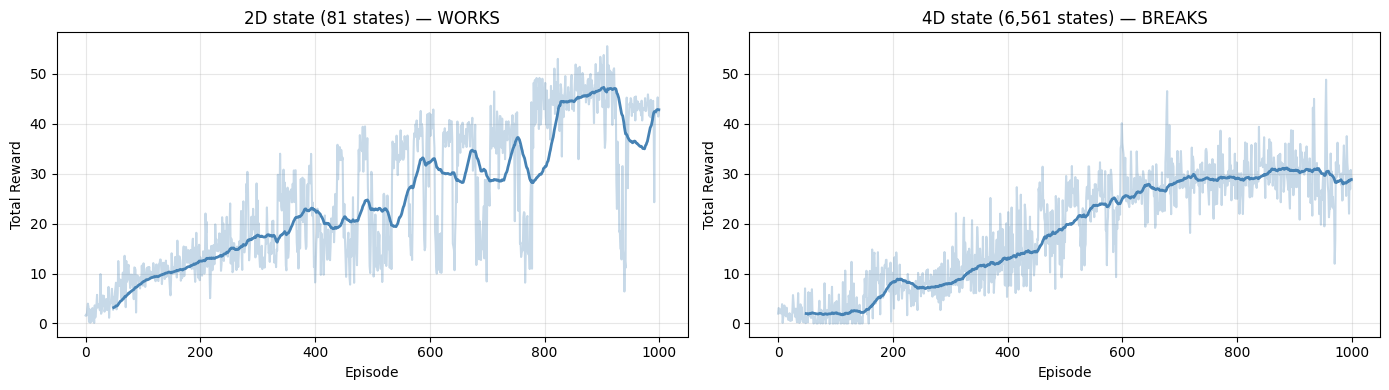


States visited at least once:
  2D state: 100% of 81 states
  4D state: 32% of 6561 states

The Q-table is mostly empty — the agent can't learn because
it rarely revisits the same (angle, angle, velocity, velocity) combination.


In [20]:
# Compare the two training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Training curves side by side
plot_rewards(rewards_2d, title='2D state (81 states) — WORKS', ax=axes[0])
plot_rewards(rewards_4d, title='4D state (6,561 states) — BREAKS', ax=axes[1])
axes[1].set_ylim(axes[0].get_ylim())  # same y-scale for fair comparison

plt.tight_layout()
plt.show()

# Show the sparsity problem
pct_2d = np.mean(visits_2d > 0) * 100
pct_4d = np.mean(visits_4d > 0) * 100
print(f'\nStates visited at least once:')
print(f'  2D state: {pct_2d:.0f}% of {N_BINS**2} states')
print(f'  4D state: {pct_4d:.0f}% of {N_BINS**4} states')
print(f'\nThe Q-table is mostly empty — the agent can\'t learn because')
print(f'it rarely revisits the same (angle, angle, velocity, velocity) combination.')

In [21]:
# Watch the 4D policy (should be visibly worse)
def q_policy_4d(obs):
    state = env_4d.discretize(obs, N_BINS)
    action = np.argmax(Q_4d[state])
    return ACTIONS_4[action]

frames_4d, dist_4d, _ = eval_policy(env_4d, q_policy_4d, 'Demo 2: Tabular Q (4D)')
show_video(frames_4d, title=f'Tabular Q-learning: 4D state — {dist_4d:.2f}m in 10s (breaks!)')

Saved rollout -> saved_rollouts/demo_2__tabular_q__4d_.npz
Demo 2: Tabular Q (4D): traveled 0.64m in 10s  (episode reward: 32.0)


### Interpreting Demo 2

This demo is more nuanced than a simple "Q-learning fails" story. In the current run, the 4D tabular agent still reaches about **0.64 m** in 10 seconds, so it does learn something useful. But after 1000 episodes it has visited only **32%** of the table.

That is the real warning sign. Once the state becomes more realistic, learning is spread over a much larger combinatorial space, and the table is only sparsely covered. So Demo 2 already exposes the scaling bottleneck even before total collapse: performance is weaker than Demo 1A, coverage is poor, and more data would be needed just to populate the table.

That directly motivates the next question:

> Can we keep the Q-learning idea, but replace the table with something that generalizes across similar states instead of storing one number per bin?


### Why did it break?

**Curse of dimensionality.** Going from 2D → 4D state increased the table from 324 to 26,244 entries. Most states are never visited, so the Q-values there are meaningless.

And this is just 4 dimensions! A humanoid has ~60D state space. With 9 bins per dimension: **9^60 ≈ 10^57 states**. No table can hold that.

**Solution:** Instead of a table, use a **neural network** to approximate Q(s, a). Nearby states get similar Q-values — the network *generalizes*.

---
## Demo 3: DQN **fixes** the continuous state problem

**Setup at a glance**

| Quantity | Notation | In this demo |
|---|---|---|
| State | $s = (\theta_{\mathrm{arm}}, \theta_{\mathrm{hand}}, \omega_{\mathrm{arm}}, \omega_{\mathrm{hand}})$ | 4D **continuous** state, no discretization |
| Action | $a \in \mathcal{A}$ | Same 4 **discrete** torque commands: $\{(+,+), (+,-), (-,+), (-,-)\}$ |
| Reward | $r_t$ | $$r_t = \frac{x_{t+1} - x_t}{\Delta t}$$ |

Same 4D state (angles + velocities), same 4 discrete actions. But instead of a table, we use a small neural network:

```
obs (4D) → [64] → [64] → Q-values (4)
```

What that means in practice:
- **`obs (4D)`** = the input state vector: `[arm angle, hand angle, arm angular velocity, hand angular velocity]`
- **first `[64]`** = a fully connected hidden layer with 64 neurons
- **second `[64]`** = another fully connected hidden layer with 64 neurons
- **`Q-values (4)`** = the output layer: one predicted value for each of the 4 discrete actions

In code, this is:

```python
nn.Linear(4, 64), nn.ReLU(),
nn.Linear(64, 64), nn.ReLU(),
nn.Linear(64, 4)
```

So this is a **small multilayer perceptron (MLP)**. It does **not** directly output torques. It outputs four scores:

$$Q_\theta(s) = [Q_\theta(s,a_1), Q_\theta(s,a_2), Q_\theta(s,a_3), Q_\theta(s,a_4)]$$

Then DQN picks the action with the largest score:

$$a^*(s) = \arg\max_a Q_\theta(s,a)$$

**Math reminder**

$$y = r + \gamma (1-d) \max_{a'} Q_{\bar\theta}(s', a')$$

$$L(\theta) = \mathbb{E}\left[\left(Q_\theta(s,a) - y\right)^2\right]$$

**Algorithm**
Initialize online network $Q_\theta$, target network $Q_{\bar\theta}$, and replay buffer $\mathcal{D}$.

Get initial state $s$.

For $k = 1, 2, \ldots$ till convergence:

Choose action $a$ with $\varepsilon$-greedy from $Q_\theta(s,\cdot)$.

Step the environment, observe $(r, s', d)$, and store $(s,a,r,s',d)$ in $\mathcal{D}$.

Sample a minibatch from $\mathcal{D}$.

$$y = r + \gamma (1-d) \max_{a'} Q_{\bar\theta}(s', a')$$

Update $\theta$ by minimizing:

$$L(\theta) = \mathbb{E}\left[\left(Q_\theta(s,a) - y\right)^2\right]$$

Every few steps, copy $\theta \rightarrow \bar\theta$.

Set $s \leftarrow s'$.

Why 64? Nothing magical here: 64 hidden units is just a small, fast network that is expressive enough for this toy crawler demo.

The network generalizes across similar states — no need to visit every state individually.

In [22]:
# ============================================================
# DQN Agent
# ============================================================

class ReplayBuffer:
    def __init__(self, capacity=20000):
        self.buffer = collections.deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        idxs = np.random.choice(len(self.buffer), batch_size, replace=False)
        batch = [self.buffer[i] for i in idxs]
        states, actions, rewards, next_states, dones = zip(*batch)
        return (np.array(states, dtype=np.float32),
                np.array(actions, dtype=np.int64),
                np.array(rewards, dtype=np.float32),
                np.array(next_states, dtype=np.float32),
                np.array(dones, dtype=np.float32))

    def __len__(self):
        return len(self.buffer)


class QNetwork(nn.Module):
    def __init__(self, obs_dim, n_actions, hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, n_actions)
        )

    def forward(self, x):
        return self.net(x)


def train_dqn(env, action_map, n_episodes=400, batch_size=64, gamma=0.99,
              lr=1e-3, eps_start=1.0, eps_end=0.01, eps_decay=0.995,
              target_update=100, buffer_size=20000, verbose=True,
              checkpoint_label=None, checkpoint_meta=None):
    """Train DQN. Returns the trained network and reward history."""
    n_actions = len(action_map)
    obs_dim = len(env.reset())

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    q_net = QNetwork(obs_dim, n_actions).to(device)
    target_net = QNetwork(obs_dim, n_actions).to(device)
    target_net.load_state_dict(q_net.state_dict())
    optimizer = optim.Adam(q_net.parameters(), lr=lr)

    buffer = ReplayBuffer(buffer_size)
    epsilon = eps_start
    rewards = []
    total_steps = 0

    def save_checkpoint(interrupted=False):
        if checkpoint_label is None:
            return
        meta = {
            'obs_dim': obs_dim,
            'n_actions': n_actions,
            'hidden': 64,
            'tracked': False,
            'double': False,
            'action_signature': action_map_signature(action_map),
            'interrupted': bool(interrupted),
            'episodes_completed': len(rewards),
        }
        if checkpoint_meta:
            meta.update(checkpoint_meta)
        state_dict_cpu = {k: v.detach().cpu() for k, v in q_net.state_dict().items()}
        save_latest_checkpoint({
            'kind': 'dqn',
            'label': checkpoint_label,
            'meta': meta,
            'state_dict': state_dict_cpu,
            'rewards': np.asarray(rewards, dtype=np.float32),
            'extras': {},
        })

    t0 = time.time()
    try:
        for ep in range(n_episodes):
            obs = env.reset()
            total_reward = 0

            while True:
                # Epsilon-greedy
                if np.random.random() < epsilon:
                    action = np.random.randint(n_actions)
                else:
                    with torch.no_grad():
                        q_vals = q_net(torch.FloatTensor(obs).unsqueeze(0).to(device))
                        action = q_vals.argmax(dim=1).item()

                next_obs, reward, terminated, truncated, _ = env.step(action_map[action])
                done = terminated or truncated
                buffer.push(obs, action, reward, next_obs, float(terminated))

                obs = next_obs
                total_reward += reward
                total_steps += 1

                # Training step
                if len(buffer) >= batch_size:
                    s, a, r, ns, d = buffer.sample(batch_size)
                    s_t = torch.FloatTensor(s).to(device)
                    a_t = torch.LongTensor(a).to(device)
                    r_t = torch.FloatTensor(r).to(device)
                    ns_t = torch.FloatTensor(ns).to(device)
                    d_t = torch.FloatTensor(d).to(device)

                    q_values = q_net(s_t).gather(1, a_t.unsqueeze(1)).squeeze(1)
                    with torch.no_grad():
                        next_q = target_net(ns_t).max(dim=1)[0]
                        target = r_t + gamma * next_q * (1 - d_t)

                    loss = nn.functional.mse_loss(q_values, target)
                    optimizer.zero_grad()
                    loss.backward()
                    optimizer.step()

                # Target network update
                if total_steps % target_update == 0:
                    target_net.load_state_dict(q_net.state_dict())

                if done:
                    break

            epsilon = max(eps_end, epsilon * eps_decay)
            rewards.append(total_reward)

            if verbose and (ep + 1) % 100 == 0:
                avg = np.mean(rewards[-50:])
                print(f'  Episode {ep+1:4d} | Avg reward: {avg:7.1f} | eps: {epsilon:.3f}')
    except KeyboardInterrupt:
        save_checkpoint(interrupted=True)
        print(f'  Training interrupted after {len(rewards)} episodes; checkpoint saved.')
        raise

    elapsed = time.time() - t0
    if verbose:
        print(f'  Training completed in {elapsed:.1f}s')

    save_checkpoint(interrupted=False)

    return q_net, rewards

In [34]:
# ---------- Demo 3: DQN on 4D state, 4 discrete actions ----------
print('=== Demo 3: DQN with 4D continuous state, 4 discrete actions ===')
print(f'State: 4D continuous (arm angle, hand angle, arm vel, hand vel)')
print(f'Actions: 4 discrete (same as before)')
print(f'Q-function: neural network (4 → 64 → 64 → 4)\n')

env_dqn = CrawlerEnv(include_velocity=True, max_steps=500)

latest = maybe_load_latest_dqn(
    obs_dim=len(env_dqn.reset()),
    action_map=ACTIONS_4,
    hidden=64,
    tracked=False,
    double=False,
    label='Demo 3: DQN (4 actions)',
    extra_meta={'demo': '3', 'variant': 'dqn_4_actions'},
)
if latest is None:
    q_net_4, rewards_dqn_4 = train_dqn(
        env_dqn, ACTIONS_4, n_episodes=1000,
        checkpoint_label='Demo 3: DQN (4 actions)',
        checkpoint_meta={'demo': '3', 'variant': 'dqn_4_actions'}
    )
else:
    q_net_4, rewards_dqn_4, _ = latest

# TODO need to train the same number of episodes as the tabular Q, to be fair.

=== Demo 3: DQN with 4D continuous state, 4 discrete actions ===
State: 4D continuous (arm angle, hand angle, arm vel, hand vel)
Actions: 4 discrete (same as before)
Q-function: neural network (4 → 64 → 64 → 4)

  Episode  100 | Avg reward:     5.3 | eps: 0.606
  Episode  200 | Avg reward:    18.3 | eps: 0.367
  Episode  300 | Avg reward:    25.6 | eps: 0.222
  Episode  400 | Avg reward:    31.8 | eps: 0.135
  Episode  500 | Avg reward:    34.7 | eps: 0.082
  Episode  600 | Avg reward:    41.1 | eps: 0.049
  Episode  700 | Avg reward:    39.9 | eps: 0.030
  Episode  800 | Avg reward:    46.8 | eps: 0.018
  Episode  900 | Avg reward:    38.2 | eps: 0.011
  Episode 1000 | Avg reward:    35.9 | eps: 0.010
  Training completed in 266.3s
Saved checkpoint -> saved_checkpoints/dqn_3_dqn_4_actions_4_4_64_False_False.pt


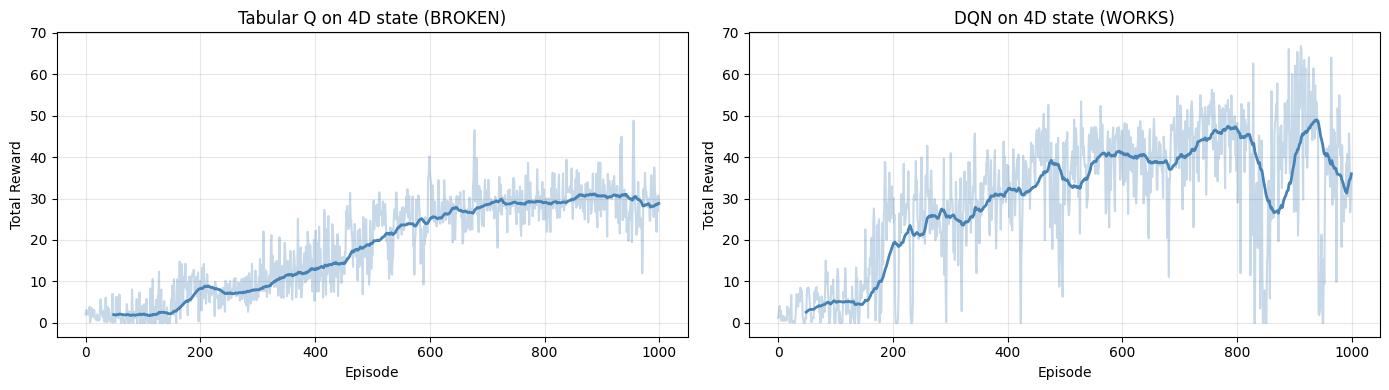

In [35]:
# Compare: tabular 4D (broken) vs DQN 4D (works)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_rewards(rewards_4d, title='Tabular Q on 4D state (BROKEN)', ax=axes[0])
plot_rewards(rewards_dqn_4, title='DQN on 4D state (WORKS)', ax=axes[1])

# Use same y-scale
ymin = min(axes[0].get_ylim()[0], axes[1].get_ylim()[0])
ymax = max(axes[0].get_ylim()[1], axes[1].get_ylim()[1])
axes[0].set_ylim(ymin, ymax)
axes[1].set_ylim(ymin, ymax)

plt.tight_layout()
plt.show()

In [36]:
# Watch the DQN policy
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def dqn_policy_4(obs):
    with torch.no_grad():
        q_vals = q_net_4(torch.FloatTensor(obs).unsqueeze(0).to(device))
        action = q_vals.argmax(dim=1).item()
    return ACTIONS_4[action]

frames_dqn, dist_dqn, _ = eval_policy(env_dqn, dqn_policy_4, 'Demo 3: DQN (4 actions)')
show_video(frames_dqn, title=f'DQN: 4D state, 4 actions — {dist_dqn:.2f}m in 10s (works!)')

Saved rollout -> saved_rollouts/demo_3__dqn__4_actions_.npz
Demo 3: DQN (4 actions): traveled 0.87m in 10s  (episode reward: 43.6)


### Interpreting Demo 3

Demo 3 answers the previous question with a clear "yes" in the current run. DQN works directly on the continuous 4D state and the saved rollout reaches about **0.87 m** in 10 seconds, essentially matching the strong 2D tabular result without discretizing the state space.

The key change is representation: the neural network shares information across nearby states instead of waiting to revisit the exact same discrete bin over and over. That is why DQN can handle the richer state where the 4D table was already showing sparse coverage.

This is the first point in the notebook where the crawler looks like a more modern RL pipeline: model-free learning, continuous state input, and function approximation. The main insight is:

> The core Q-learning idea is still useful, but the representation has to change once the state space becomes too large for tables.


---
## Demo 3A: The Deadly Triad — why DQN needs its tricks

**Setup at a glance**

| Quantity | Notation | In this demo |
|---|---|---|
| State | $s = (\theta_{\mathrm{arm}}, \theta_{\mathrm{hand}}, \omega_{\mathrm{arm}}, \omega_{\mathrm{hand}})$ | Same 4D **continuous** state as Demo 3 |
| Action | $a \in \mathcal{A}$ | Same 4 **discrete** torque commands: $\{(+,+), (+,-), (-,+), (-,-)\}$ |
| Reward | $r_t$ | $$r_t = \frac{x_{t+1} - x_t}{\Delta t}$$ |

DQN works because of two key stabilization tricks:
1. **Replay buffer** — decorrelates samples (breaks the sequential correlation of on-policy data)
2. **Target network** — stabilizes the bootstrap target (prevents chasing a moving target)

Without these, the combination of **function approximation + bootstrapping + off-policy learning** (the "deadly triad") makes training diverge.

**Math reminder**

**Standard DQN target:**  $$y = r + \gamma (1-d) \max_{a'} Q_{\bar\theta}(s', a')$$

**Double DQN target:**  $$a^* = \arg\max_{a'} Q_\theta(s',a'), \qquad y = r + \gamma (1-d) Q_{\bar\theta}(s', a^*)$$

**Ablation procedure**
Start from the Demo 3 DQN algorithm.

Keep the same state, action set, reward, and network.

Then remove one stabilizer at a time: no target network, or no replay buffer.

Train each variant and compare the reward curves against full DQN.

Let's **ablate** each trick and see what happens.

In [26]:
# ---------- Demo 3A: Ablation study ----------
print("=== Demo 3A: What happens without DQN's stabilization tricks? ===")
print('We use lr=3e-3 (3x default) to stress-test stability.\n')
print('Each variant now has its own checkpoint file, so reruns can reload cleanly after a crash.\n')

env_triad = CrawlerEnv(include_velocity=True, max_steps=500)

# Variant 1: No target network (target_update=1 means target = online net every step)
print('--- Variant 1: No target network (target updates every step) ---')
latest = maybe_load_latest_dqn(
    obs_dim=len(env_triad.reset()),
    action_map=ACTIONS_4,
    hidden=64,
    tracked=False,
    double=False,
    label='Demo 3A: No target network',
    extra_meta={'demo': '3A', 'variant': 'no_target'},
)
if latest is None:
    _, rewards_no_target = train_dqn(
        env_triad, ACTIONS_4, n_episodes=1000,
        target_update=1, lr=3e-3,
        checkpoint_label='Demo 3A: No target network',
        checkpoint_meta={'demo': '3A', 'variant': 'no_target'}
    )
else:
    _, rewards_no_target, _ = latest

# Variant 2: Tiny replay buffer (effectively no replay — always trains on recent data)
print('\n--- Variant 2: No replay buffer (buffer_size=64, same as batch) ---')
latest = maybe_load_latest_dqn(
    obs_dim=len(env_triad.reset()),
    action_map=ACTIONS_4,
    hidden=64,
    tracked=False,
    double=False,
    label='Demo 3A: No replay buffer',
    extra_meta={'demo': '3A', 'variant': 'no_replay'},
)
if latest is None:
    _, rewards_no_replay = train_dqn(
        env_triad, ACTIONS_4, n_episodes=1000,
        buffer_size=64, lr=3e-3,
        checkpoint_label='Demo 3A: No replay buffer',
        checkpoint_meta={'demo': '3A', 'variant': 'no_replay'}
    )
else:
    _, rewards_no_replay, _ = latest

print('\nDone! Compare against full DQN (rewards_dqn_4) from Demo 3.')


=== Demo 3A: What happens without DQN's stabilization tricks? ===
We use lr=3e-3 (3x default) to stress-test stability.

Each variant now has its own checkpoint file, so reruns can reload cleanly after a crash.

--- Variant 1: No target network (target updates every step) ---
  Episode  100 | Avg reward:     0.0 | eps: 0.606
  Episode  200 | Avg reward:    -0.0 | eps: 0.367
  Episode  300 | Avg reward:    -0.0 | eps: 0.222
  Episode  400 | Avg reward:    -0.0 | eps: 0.135
  Episode  500 | Avg reward:     2.3 | eps: 0.082
  Episode  600 | Avg reward:     1.8 | eps: 0.049
  Episode  700 | Avg reward:     6.9 | eps: 0.030
  Episode  800 | Avg reward:    -0.0 | eps: 0.018
  Episode  900 | Avg reward:     7.8 | eps: 0.011
  Episode 1000 | Avg reward:    23.3 | eps: 0.010
  Training completed in 240.2s
Saved checkpoint -> saved_checkpoints/dqn_3A_no_target_4_4_64_False_False.pt

--- Variant 2: No replay buffer (buffer_size=64, same as batch) ---
  Episode  100 | Avg reward:     4.2 | eps: 0.

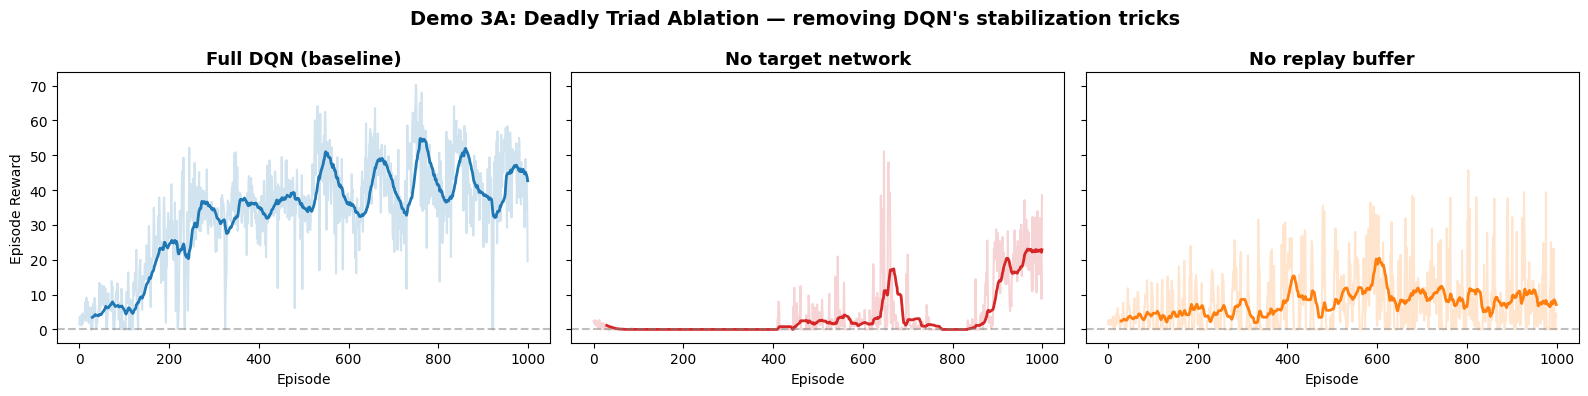

Full DQN (baseline)      : last-50 avg = 43.9
No target network        : last-50 avg = 23.3
No replay buffer         : last-50 avg = 7.0


In [30]:
# Plot ablation results
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
window = 30

data = [
    ('Full DQN (baseline)', rewards_dqn_4, 'tab:blue'),
    ('No target network', rewards_no_target, 'tab:red'),
    ('No replay buffer', rewards_no_replay, 'tab:orange'),
]

for ax, (title, rewards, color) in zip(axes, data):
    ax.plot(rewards, alpha=0.2, color=color)
    smoothed = np.convolve(rewards, np.ones(window)/window, mode='valid')
    ax.plot(np.arange(window-1, len(rewards)), smoothed, color=color, lw=2)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Episode')
    ax.axhline(y=0, color='gray', ls='--', alpha=0.5)

axes[0].set_ylabel('Episode Reward')
fig.suptitle('Demo 3A: Deadly Triad Ablation — removing DQN\'s stabilization tricks',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print summary
for title, rewards, _ in data:
    last50 = np.mean(rewards[-50:])
    print(f'{title:25s}: last-50 avg = {last50:.1f}')

### Interpreting Demo 3A

The current ablation makes the stabilization story concrete. Full DQN in Demo 3 finishes around **35.9** average reward over the last logged window. Without a target network, training is highly erratic -- it spends long stretches near zero before only partially recovering to **23.3** by episode 1000. Without replay, learning is more consistently bad and ends around **7.0**.

So Demo 3A shows that "use a neural network" is not enough. Once we combine function approximation, bootstrapping, and off-policy learning, naive Q-learning can become unstable. Replay and target networks are not cosmetic implementation details; they are what make DQN train reliably enough to be useful.

In other words, neural networks fix the state-scaling problem, but they introduce a new optimization and stability problem that needs additional machinery.


### Takeaway: The Deadly Triad and its Solutions

| Problem | Cause | Solution |
|---------|-------|----------|
| Training divergence | Correlated sequential samples | **Replay buffer** — sample uniformly from past experience |
| Training divergence | Bootstrapping from a moving target | **Target network** — freeze target for N steps |
| Q-value overestimation | `max` operator amplifies noise | **Double DQN** — decouple action selection from evaluation |

These three tricks turn unstable Q-learning into the stable **DQN** algorithm that conquered Atari (Mnih et al., 2015).

**But DQN still requires discrete actions.** What if we need continuous control? → Demo 4

---
## Demo 4: DQN **breaks** with continuous actions

**Setup at a glance**

| Quantity | Notation | In this demo |
|---|---|---|
| State | $s = (\theta_{\mathrm{arm}}, \theta_{\mathrm{hand}}, \omega_{\mathrm{arm}}, \omega_{\mathrm{hand}})$ | Same 4D **continuous** state as Demo 3 |
| Action | $a = (\tau_{\mathrm{arm}}, \tau_{\mathrm{hand}})$ | True control is **continuous**, but DQN only sees a discretized grid: $m$ torque levels per joint $\Rightarrow m^2$ actions |
| Reward | $r_t$ | $$r_t = \frac{x_{t+1} - x_t}{\Delta t}$$ |

Our 4 discrete actions (all combos of ±1 torque) are crude — real motors apply **continuous torques**.

DQN needs `argmax_a Q(s, a)` — easy when there are 4 actions, but **impossible** when actions are continuous (infinite choices).

**Math reminder**

$$a^*(s) = \arg\max_a Q_\theta(s,a)$$

This is cheap for a small finite action set, but not for a continuous action vector.

If we discretize each joint into `m` torque levels, then the crawler has `m^2` discrete actions.

**Algorithm**
Reuse the same DQN algorithm as Demo 3, but replace the 4-action set with a finer discretized torque grid.

For each choice of $m$ torque levels per joint:

$$|\mathcal{A}| = m^2$$

Train DQN on that discrete action set and compare learning as $m$ increases.

The only change is the size of the `argmax` over actions.

Workaround: discretize torques into a grid. Let's try:
- **Coarse:** 3 torque levels per joint → 9 actions
- **Fine:** 7 torque levels per joint → 49 actions
- **Very fine:** 11 levels → 121 actions

In [42]:
# ---------- Demo 4: DQN struggles with discretized continuous actions ----------

results = {}

for n_torque_bins, n_eps in [(3, 1000), (7, 1000), (11, 1000)]:
    action_map = make_fine_actions(n_torque_bins)
    n_act = len(action_map)
    print(f'\n=== DQN with {n_torque_bins} torque levels → {n_act} actions ===')

    env_cont = CrawlerEnv(include_velocity=True, max_steps=500)

    latest = maybe_load_latest_dqn(
        obs_dim=len(env_cont.reset()),
        action_map=action_map,
        hidden=64,
        tracked=False,
        double=False,
        label=f'Demo 4: DQN ({n_act} actions)',
        extra_meta={'demo': '4', 'variant': f'{n_torque_bins}_bins'},
    )
    if latest is None:
        q_net, rews = train_dqn(
            env_cont, action_map, n_episodes=n_eps,
            eps_decay=0.997, lr=5e-4,
            checkpoint_label=f'Demo 4: DQN ({n_act} actions)',
            checkpoint_meta={'demo': '4', 'variant': f'{n_torque_bins}_bins'}
        )
    else:
        q_net, rews, _ = latest
    results[n_torque_bins] = (q_net, rews, action_map)


=== DQN with 3 torque levels → 9 actions ===
Loaded checkpoint for Demo 4: DQN (9 actions); skipping retraining.
  path: saved_checkpoints/dqn_4_3_bins_4_9_64_False_False.pt

=== DQN with 7 torque levels → 49 actions ===
Loaded checkpoint for Demo 4: DQN (49 actions); skipping retraining.
  path: saved_checkpoints/dqn_4_7_bins_4_49_64_False_False.pt

=== DQN with 11 torque levels → 121 actions ===
  Episode  100 | Avg reward:     1.4 | eps: 0.740
  Episode  200 | Avg reward:     3.1 | eps: 0.548
  Episode  300 | Avg reward:     2.7 | eps: 0.406
  Episode  400 | Avg reward:     2.9 | eps: 0.301
  Episode  500 | Avg reward:     9.1 | eps: 0.223
  Episode  600 | Avg reward:    14.1 | eps: 0.165
  Episode  700 | Avg reward:    18.8 | eps: 0.122
  Episode  800 | Avg reward:    22.3 | eps: 0.090
  Episode  900 | Avg reward:    17.6 | eps: 0.067
  Episode 1000 | Avg reward:    18.8 | eps: 0.050
  Training completed in 252.1s
Saved checkpoint -> saved_checkpoints/dqn_4_11_bins_4_121_64_False_

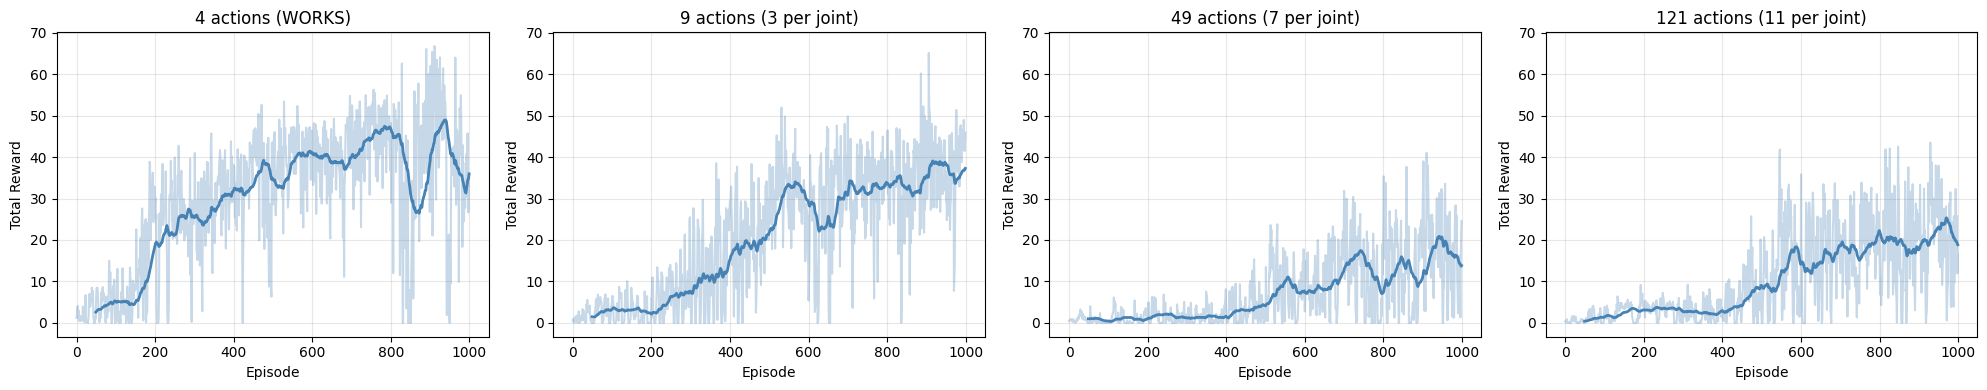


As we increase action resolution, DQN struggles more:
  4 actions:   avg last-50 reward = 35.9
    9 actions: avg last-50 reward = 37.3
   49 actions: avg last-50 reward = 13.8
  121 actions: avg last-50 reward = 18.8


In [43]:
# Compare all DQN results
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

# Reference: DQN with 4 actions (works)
plot_rewards(rewards_dqn_4, title='4 actions (WORKS)', ax=axes[0])

for i, (n_bins, (_, rews, _)) in enumerate(results.items()):
    n_act = n_bins ** 2
    plot_rewards(rews, title=f'{n_act} actions ({n_bins} per joint)', ax=axes[i+1])

# Same y-scale across all plots
all_ylims = [ax.get_ylim() for ax in axes]
ymin = min(y[0] for y in all_ylims)
ymax = max(y[1] for y in all_ylims)
for ax in axes:
    ax.set_ylim(ymin, ymax)

plt.tight_layout()
plt.show()

print('\nAs we increase action resolution, DQN struggles more:')
print(f'  4 actions:   avg last-50 reward = {np.mean(rewards_dqn_4[-50:]):.1f}')
for n_bins, (_, rews, _) in results.items():
    print(f'  {n_bins**2:3d} actions: avg last-50 reward = {np.mean(rews[-50:]):.1f}')

In [44]:
# Animate the worst case (most actions) to show the jerky/failed behavior
worst_bins = max(results.keys())
worst_net, _, worst_actions = results[worst_bins]

env_show = CrawlerEnv(include_velocity=True, max_steps=500)

def dqn_policy_fine(obs):
    with torch.no_grad():
        q_vals = worst_net(torch.FloatTensor(obs).unsqueeze(0).to(device))
        action = q_vals.argmax(dim=1).item()
    return worst_actions[action]

frames_fine, dist_fine, _ = eval_policy(
    env_show, dqn_policy_fine, f'Demo 4: DQN ({worst_bins**2} actions)')
show_video(frames_fine, title=f'DQN with {worst_bins**2} actions — {dist_fine:.2f}m in 10s (breaks!)')

Saved rollout -> saved_rollouts/demo_4__dqn__121_actions_.npz
Demo 4: DQN (121 actions): traveled 0.08m in 10s  (episode reward: 4.1)


### Interpreting Demo 4

Demo 4 exposes the final bottleneck in this notebook. DQN handled the **state** problem in Demo 3, but it still depends on an `argmax` over a discrete action list. When that action list becomes very fine, the method becomes awkward again.

In the current run, the saved **121-action** DQN rollout travels only about **0.08 m** in 10 seconds, compared with **0.87 m** for the 4-action DQN. So making the torque grid finer does not magically give better control here; it makes the discrete search problem harder.

This connects directly back to the title of the notebook: we went from Value Iteration to DQN, and we still end up needing something else. The missing ingredient is a method that can work with **continuous actions directly**, without enumerating a huge action grid.


In [45]:
# Save reusable policies for the policy-gradient notebook comparison
save_path = Path('saved_policies')
save_path.mkdir(exist_ok=True)

dqn_checkpoint = {
    'q_net_state_dict': q_net_4.state_dict(),
    'obs_dim': 4,
    'n_actions': 4,
    'hidden': 64,
    'rewards': np.asarray(rewards_dqn_4, dtype=np.float32),
    'action_map': {int(k): v.tolist() for k, v in ACTIONS_4.items()},
}
torch.save(dqn_checkpoint, save_path / 'dqn_crawler_4act.pt')
print(f'Saved DQN policy to {save_path / "dqn_crawler_4act.pt"}')
print(f'  obs_dim={dqn_checkpoint["obs_dim"]}, n_actions={dqn_checkpoint["n_actions"]}, hidden={dqn_checkpoint["hidden"]}')
print(f'  saved training curve with {len(dqn_checkpoint["rewards"])} episodes')

tabular_checkpoint = {
    'Q': Q_2d,
    'n_bins': N_BINS,
    'include_velocity': False,
    'angle_lo': float(env_2d.angle_lo),
    'angle_hi': float(env_2d.angle_hi),
    'action_map': {int(k): v.tolist() for k, v in ACTIONS_4.items()},
}
torch.save(tabular_checkpoint, save_path / 'tabular_q_2d.pt')
print(f'Saved tabular Q policy to {save_path / "tabular_q_2d.pt"}')
print(f'  Q shape={tabular_checkpoint["Q"].shape}, n_bins={tabular_checkpoint["n_bins"]}')

Saved DQN policy to saved_policies/dqn_crawler_4act.pt
  obs_dim=4, n_actions=4, hidden=64
  saved training curve with 1000 episodes
Saved tabular Q policy to saved_policies/tabular_q_2d.pt
  Q shape=(9, 9, 4), n_bins=9


### Why did DQN break?

DQN needs to evaluate **every possible action** to pick the best one (argmax). When we discretize continuous torques:

- **Too few bins (coarse):** The controller can't produce smooth motion — like driving a car where the steering wheel only has 3 positions.
- **Too many bins (fine):** The action space explodes. The network struggles to figure out that torque=0.71 is almost as good as torque=0.73.

For a real robot with 20 joints, even 3 torque levels per joint gives **3^20 ≈ 3.5 billion** discrete actions. Impossible.

---

### What we need

Instead of asking *"which of these N discrete actions is best?"*, we need a method that **directly outputs continuous values**:

$$\pi_\theta(s) \rightarrow a \in \mathbb{R}^n$$

A **policy network** that takes the state and directly outputs torques. No argmax, no enumeration.

How do we train it? **Policy gradient methods** — the topic of the next lecture.

The idea: instead of learning Q-values and deriving a policy, directly optimize the policy parameters by gradient ascent on expected reward.

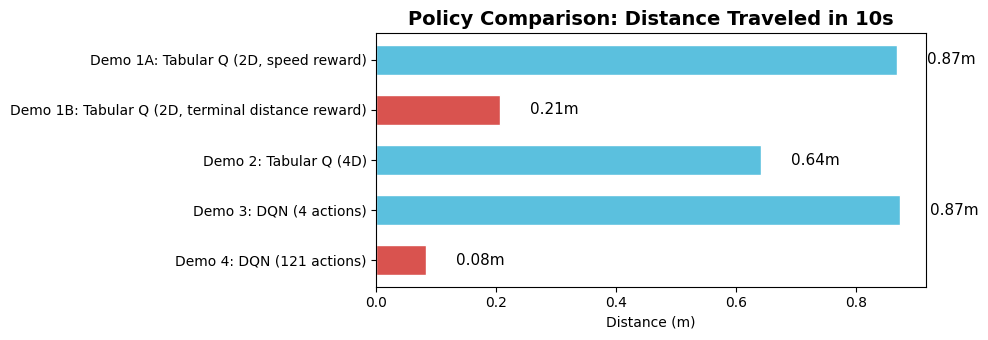

In [46]:
# ============================================================
# Final comparison: how far does each policy get in 10 seconds?
# ============================================================
eval_results_final = {
    label: dist for label, dist in eval_results.items()
    if not label.startswith('Sensitivity sweep:')
}
plot_eval_comparison(eval_results_final)

---
## Summary

| Method | State | Actions | Result | Distance (10s) | Bottleneck |
|--------|-------|---------|--------|----------------|------------|
| **Value Iteration (0A)** | 2D (81 states) | 4 discrete | Solver converges, behavior still weak | 0.03m | Needs model access + coarse model |
| **Value Iteration (0B)** | 4D (6561 states) | 4 discrete | Tiny behavioral gain, huge runtime cost | 0.04m | Better state, but huge model cost |
| **Policy Iteration (0C)** | 4D (6561 states) | 4 discrete | Same result as VI | 0.04m | Solver change does not fix bad model |
| **Tabular Q (1A)** | 2D (81 states) | 4 discrete | Works well | 0.87m | Model-free learning on coarse state |
| **Tabular Q (1B)** | 2D (81 states) | 4 discrete | Worse with sparse terminal reward | 0.21m | Reward design / credit assignment |
| **Tabular Q (2)** | 4D (6561 states) | 4 discrete | Partial success, sparse coverage | 0.64m | Curse of dimensionality |
| **DQN (3)** | 4D (continuous) | 4 discrete | Works well | 0.87m | Function approximation helps state scaling |
| **DQN (4, 121 actions)** | 4D (continuous) | 121 discretized | Breaks again | 0.08m | Discrete actions only |

Most demos above use the same forward-speed reward,
$$r_t = \frac{x_{t+1} - x_t}{\Delta t},$$
but Demo 1B intentionally switches to a terminal-distance reward to show that **reward design alone** can change the learned behavior even when the algorithm, state, and action space stay fixed.

For Demo 0, the 20-trial average reward is better than random, but the single rendered rollout is still only 0.03 m and the single random teaser rollout happens to be 0.06 m. Treat that as a reminder that one rollout can be noisy; the robust conclusion is that exact planning is still behaviorally weak on this coarse model.

For Demo 4, the currently visible logs show the 4-action DQN ending around **35.9** average reward and the freshly trained 121-action run ending around **18.8**. The key point is that the saved 121-action rollout is still poor, so a finer discrete action grid does not solve the continuous-control problem.

Each method's limitation motivates the next:
- VI needs the model -> **Q-learning** learns from experience
- Tabular Q can't scale -> **DQN** uses neural network
- DQN needs discrete actions -> **Policy Gradient** works with continuous actions

**How did these demos answer the question raised at the beginning?**

The notebook started with a progression question: why do we keep moving from Value Iteration to tabular Q-learning to DQN, and then still need policy-gradient methods? The demos now give a concrete answer.

- **Exact planning** can solve a small tabular model quickly, but only if the state abstraction and transition model are actually good enough.
- **Tabular model-free learning** avoids building a global model and can work better on real rollouts, but it still runs into a state-space scaling problem.
- **DQN** fixes the large-state problem by replacing the table with a neural network, but then stability tricks become essential.
- Even after that, **continuous action control** remains unresolved, because DQN still depends on an `argmax` over a discrete action list.

So the main lesson is not that one algorithm is universally best. The lesson is that **each method solves one bottleneck and then exposes the next one**. Using the same crawler across all demos makes that chain of tradeoffs visible.

The 2D tabular Q policy and the 4-action DQN policy have been saved to `saved_policies/` for comparison in the next notebook.

**Next up:** `L6-2_demo_crawler_pg.ipynb` -- REINFORCE and Actor-Critic on the same crawler with continuous actions.
